# Predicción de congestión urbana

## Contexto del problema

El Ayuntamiento de una ciudad inteligente quiere anticipar episodios de congestión alta para apoyar decisiones operativas como ajustes semafóricos o avisos al ciudadano.

Para ello dispone de un dataset con variables de movilidad, contexto meteorológico, operación del transporte y otras señales auxiliares provenientes de sensores distribuidos por la ciudad.

El objetivo es construir un modelo que identifique casos de congestión alta y justificar las decisiones tomadas hasta llegar a un modelo robusto y adaptado a las necesidades operativas del Ayuntamiento.

## Librerias empleadas

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt # modulo especifico de gráficos
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
import optuna
import shap
import numpy as np
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
# estan en orden


> Duda más normal en este punto: ¿Por qué imputar lluvia pero en este caso franja horaria con la moda no? franja_horaria es categórica: sus valores son etiquetas (Mañana, Tarde, Noche). La moda sería imputar todos los nulos con "Tarde" por ejemplo, pero eso introduce información falsa en una variable muy discriminativa. Si esos 9 registros son en realidad de noche y los imputamos como tarde, el modelo aprende mal. Con tan pocos registros es más limpio eliminarlos. En cambio, lluvia_mm es numérica: la mediana es un valor representativo y plausible, no introduce información falsa. En variables categóricas el error de imputación es binario, o aciertas la categoría correcta o te equivocas completamente. En variables numéricas hay un gradiente ya que puedes estar más o menos cerca del valor real, y la mediana es una aproximación razonable que introduce poco error.


## Exploración del caso de uso a estudiar

En esta sección se define el problema antes de tocar los datos. El objetivo es responder a las preguntas clave del caso de uso: qué se quiere predecir, quién usará el modelo y qué decisiones operativas permitirá tomar.

### Carga de datos

In [2]:
data = pd.read_csv('../data/dataset_smart_urban_mobility.csv')

print(f"Dimensiones dataset", data.shape)
print(f"Columnas del dataset",data.columns)
data.head()

Dimensiones dataset (720, 26)
Columnas del dataset Index(['id_registro', 'fecha', 'dia_semana_num', 'distrito', 'tipo_dia',
       'franja_horaria', 'id_sensor', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'color_semaforo_dominante', 'campana_publicitaria',
       'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta'],
      dtype='str')


,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1
1,2,2025-01-01,2,Centro,Laborable,Mañana,S-028,12.6,54.0,12.9,...,70.4,73.0,24.9,8.0,97.6,Amarillo,0,52.8,62.2,1
2,3,2025-01-02,3,Este,Laborable,Tarde,S-003,22.0,39.0,2.8,...,75.8,136.0,42.4,9.0,100.2,Rojo,1,50.0,62.5,0
3,4,2025-01-02,3,Universidad,Laborable,Mañana,S-032,22.6,49.0,0.4,...,88.0,142.0,38.0,7.0,93.1,Amarillo,0,52.7,61.8,1
4,5,2025-01-03,4,Centro,Laborable,Tarde,S-001,19.3,44.0,3.6,...,79.1,141.0,21.0,12.0,96.2,Rojo,0,54.3,77.5,1


El dataset tiene 720 registros o observaciones y 26 variables o columnas

Para entender mejor qué representa cada fila del dataset, veamos un registro concreto:

In [3]:
data.head(1)

,id_registro,fecha,dia_semana_num,distrito,tipo_dia,franja_horaria,id_sensor,temperatura_c,humedad_relativa_pct,lluvia_mm,...,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,porcentaje_hombres_zona,indice_congestion,congestion_alta
0,1,2025-01-01,2,Centro,Laborable,Mañana,S-050,14.1,61.0,3.5,...,71.9,168.0,30.4,8.0,91.5,Verde,0,52.3,68.7,1


| Campo | Valor | Interpretación |
|---|---|---|
| `id_registro` | 1 | Primera fila del dataset |
| `fecha` | 2025-01-01 | 1 de enero de 2025 |
| `dia_semana_num` | 2 | Miércoles |
| `distrito` | Centro | Distrito Centro de la ciudad |
| `tipo_dia` | Laborable | Día entre semana |
| `franja_horaria` | Mañana | Registro tomado por la mañana |
| `id_sensor` | S-050 | Sensor número 50 |
| `temperatura_c` | 14.1°C | Temperatura fresca, típica de enero |
| `humedad_relativa_pct` | 61% | Humedad moderada |
| `lluvia_mm` | 3.5mm | Lluvia ligera |
| `ocupacion_bus_pct` | 71.9% | El autobús va bastante lleno |
| `plazas_aparcamiento_libres` | 168 | Bastantes plazas libres |
| `ocupacion_bici_pct` | 30.4% | Uso moderado de bicicletas |
| `numero_incidencias_app` | 8 | 8 incidencias reportadas por usuarios |
| `indice_ruido_historico` | 91.5 | Zona ruidosa |
| `color_semaforo_dominante` | Verde | Semáforos en verde predominantemente |
| `campana_publicitaria` | 0 | Sin campaña publicitaria activa |
| `porcentaje_hombres_zona` | 52.3% | Distribución casi equitativa por género |
| `indice_congestion` | 68.7 | Nivel de congestión moderado-alto |
| `congestion_alta` | **1** | **Hay congestión alta** |

Es decir, este registro representa una mañana de miércoles laborable en el distrito Centro, con lluvia ligera, autobuses bastante ocupados y 8 incidencias reportadas en la app. El resultado es congestión alta.

### Exploración de las variables 

El objetivo en esta sección es poder presentar una tabla con todas las variables y lo que significa cada una. Antes de nada, exploramos las distintas variables:

In [4]:
print(data['id_registro'].nunique()) # id_registro es un indice de las filas, hay tantos como filas
print(data['fecha'].value_counts().head(3)) # fecha del registro
print(data['dia_semana_num'].value_counts()) # dia de la semana codificado numericamente de L-D 0-6
print(data['distrito'].value_counts()) # distrito del registro
print(f"La variable distrito tiene estas opciones",data['distrito'].unique())

720
fecha
2025-01-01    2
2025-01-02    2
2025-01-03    2
Name: count, dtype: int64
dia_semana_num
2    104
3    104
4    104
5    102
6    102
0    102
1    102
Name: count, dtype: int64
distrito
Centro         136
Este           123
Norte          123
Universidad    118
Oeste          108
Sur            103
Name: count, dtype: int64
La variable distrito tiene estas opciones <StringArray>
['Centro', 'Este', 'Universidad', 'Sur', 'Oeste', 'Norte', nan]
Length: 7, dtype: str


In [5]:
print(data['tipo_dia'].value_counts()) # laborable o fin de semana
print(data['franja_horaria'].value_counts()) # tarde,mañana o noche
print(f"Número de sensores unicos con id del tipo S-Número:",data['id_sensor'].nunique()) # 50 sensores unicos 

tipo_dia
Laborable        516
Fin de semana    204
Name: count, dtype: int64
franja_horaria
Tarde     277
Mañana    274
Noche     160
Name: count, dtype: int64
Número de sensores unicos con id del tipo S-Número: 50


In [6]:
# variables numéricas claras
data[['temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh',  'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'porcentaje_hombres_zona', 'indice_congestion']].describe()

,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,aforo_vehiculos,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,porcentaje_hombres_zona,indice_congestion
count,713.000000,716.000000,710.000000,717.000000,720.000000,715.000000,715.000000,718.000000,718.000000,716.000000,717.000000,720.000000,720.000000
mean,16.609397,58.925978,3.344366,12.745328,1503.355556,3.724476,69.385874,179.792479,35.278969,7.956704,88.024826,51.535833,61.268333
std,7.444073,13.787553,4.044703,4.841579,473.639389,1.334062,13.294684,49.651366,10.261256,3.160432,11.891769,1.278394,11.296092
min,-10.100000,25.000000,0.000000,0.000000,350.000000,0.000000,28.500000,31.000000,1.200000,0.000000,58.400000,48.000000,23.900000
25%,11.100000,49.000000,0.300000,9.500000,1184.750000,3.000000,60.900000,147.000000,28.000000,6.000000,80.200000,50.600000,54.075000
50%,16.400000,59.000000,2.100000,12.700000,1522.000000,4.000000,69.900000,179.000000,34.850000,8.000000,88.100000,51.600000,61.850000
75%,22.200000,68.000000,4.800000,15.800000,1842.250000,5.000000,78.700000,211.000000,42.200000,10.000000,96.000000,52.500000,68.525000
max,38.000000,95.000000,28.500000,28.300000,2785.000000,7.000000,100.000000,327.000000,66.900000,18.000000,125.000000,55.200000,92.600000


In [7]:
data['color_semaforo_dominante'].value_counts()

color_semaforo_dominante
Verde       266
Rojo        235
Amarillo    219
Name: count, dtype: int64

In [8]:
# variables binarias
print(data['evento_ciudad'].unique())
print(data['obras_viales'].unique())
print(data[ 'festivo_local'].unique())
print(data['campana_publicitaria'].unique())

[0 1]
[0 1]
[0 1]
[0 1]


In [9]:
# episodios de congestión alta
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

| Variable | Tipo | Descripción |
|---|---|---|
| `id_registro` | Índice | Identificador único de cada fila, no aporta información predictiva |
| `fecha` | Fecha | Fecha del registro (2025, datos diarios) |
| `dia_semana_num` | Numérica discreta | Día de la semana codificado de 0 (lunes) a 6 (domingo) |
| `distrito` | Categórica | Distrito de la ciudad: Centro, Este, Norte, Sur, Oeste, Universidad. Tiene valores nulos |
| `tipo_dia` | Categórica binaria | Laborable o Fin de semana |
| `franja_horaria` | Categórica | Franja del día: Mañana, Tarde, Noche |
| `id_sensor` | Categórica | Identificador del sensor que recoge el registro. 50 sensores únicos |
| `temperatura_c` | Numérica continua | Temperatura en grados Celsius. Rango de -10 a 38°C. Tiene valores nulos |
| `humedad_relativa_pct` | Numérica continua | Humedad relativa en porcentaje (25-95%). Tiene valores nulos |
| `lluvia_mm` | Numérica continua | Precipitación en milímetros. Tiene valores nulos |
| `viento_kmh` | Numérica continua | Velocidad del viento en km/h. Tiene valores nulos |
| `evento_ciudad` | Binaria (0/1) | Si hay un evento en la ciudad ese día |
| `obras_viales` | Binaria (0/1) | Si hay obras en la vía ese día |
| `festivo_local` | Binaria (0/1) | Si es festivo local |
| `aforo_vehiculos` | Numérica continua | Número de vehículos registrados por el sensor (350-2785) |
| `accidentes_previos_24h` | Numérica discreta | Número de accidentes en las últimas 24 horas. Tiene valores nulos |
| `ocupacion_bus_pct` | Numérica continua | Porcentaje de ocupación del autobús (28-100%). Tiene valores nulos |
| `plazas_aparcamiento_libres` | Numérica continua | Número de plazas de aparcamiento libres. Tiene valores nulos |
| `ocupacion_bici_pct` | Numérica continua | Porcentaje de ocupación del servicio de bicicletas. Tiene valores nulos |
| `numero_incidencias_app` | Numérica discreta | Número de incidencias reportadas por usuarios en la app. Tiene valores nulos |
| `indice_ruido_historico` | Numérica continua | Índice de ruido histórico de la zona. Tiene valores nulos |
| `color_semaforo_dominante` | Categórica | Color de semáforo predominante en la zona: verde, rojo o amarillo |
| `campana_publicitaria` | Binaria (0/1) | Si hay campaña publicitaria activa en la zona |
| `porcentaje_hombres_zona` | Numérica continua | Porcentaje de hombres en la zona (48-55%) |
| `indice_congestion` | Numérica continua | Índice numérico de congestión (23.9-92.6) |
| `congestion_alta` | Binaria (0/1) — **variable objetivo** | Si hay congestión alta (1) o no (0). 531 casos positivos de 720 |

### Identificación de la variable objetivo

La variable objetivo es `congestion_alta`, una variable binaria que indica si en ese registro se ha producido un episodio de congestión alta (1) o no (0).

In [10]:
data['congestion_alta'].value_counts()

congestion_alta
1    531
0    189
Name: count, dtype: int64

In [11]:
data['congestion_alta'].value_counts(normalize=True) * 100 # porcentajes

congestion_alta
1    73.75
0    26.25
Name: proportion, dtype: float64

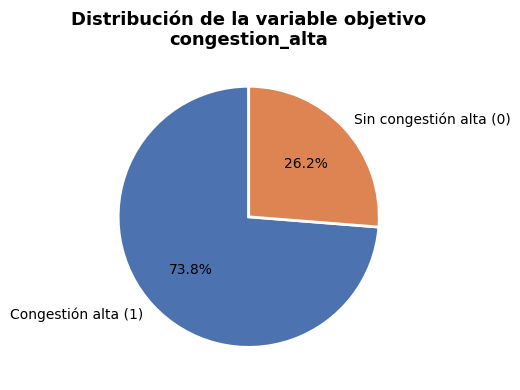

In [12]:
conteo_target = data['congestion_alta'].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(
    conteo_target.values,
    labels=[ 'Congestión alta (1)','Sin congestión alta (0)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Distribución de la variable objetivo\ncongestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Del total de 720 registros, 531 corresponden a congestión alta y 189 a no congestión. Esto significa que el dataset está **desbalanceado**. El 73.75% de los casos son positivos. Este desbalance es importante tenerlo en cuenta a la hora de entrenar el modelo, ya que un clasificador que predijera siempre congestión alta acertaría el 73.75% de las veces sin aprender nada útil.

Otra variable que podría generar dudas es `indice_congestion`. Esta variable numérica continua podría usarse como variable objetivo si el problema fuera de **regresión**, es decir, si quisiéramos predecir el nivel exacto de congestión como un número.

Sin embargo, el problema está planteado como **clasificación binaria**: predecir si hay congestión alta o no. Por eso la variable objetivo es `congestion_alta` (0 o 1), no `indice_congestion`.

Es muy probable que `congestion_alta` se haya derivado directamente de `indice_congestion` aplicando un umbral fijo (pregunta que hay que demostrar):

- congestion_alta = 1  si  indice_congestion > umbral X
- congestion_alta = 0  si  indice_congestion ≤ umbral X

Si esto es así, los registros con `congestion_alta = 0` deberían tener valores de `indice_congestion` siempre por debajo de ese umbral, y los de `congestion_alta = 1` siempre por encima. Vemos si esta afirmación es correcta:

In [13]:
data['indice_congestion'].describe()

count    720.000000
mean      61.268333
std       11.296092
min       23.900000
25%       54.075000
50%       61.850000
75%       68.525000
max       92.600000
Name: indice_congestion, dtype: float64

In [14]:
data.groupby('congestion_alta')['indice_congestion'].describe()

,count,mean,std,min,25%,50%,75%,max
congestion_alta,,,,,,,,
0,189.0,53.692593,9.994208,23.9,47.00,54.5,60.60,79.9
1,531.0,63.964783,10.484446,33.9,57.05,64.0,70.85,92.6


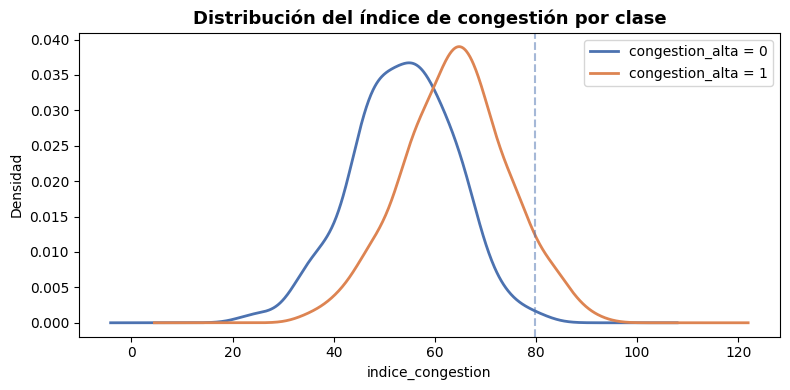

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = data[data['congestion_alta'] == label]['indice_congestion']
    subset.plot(kind='kde', ax=ax, label=f'congestion_alta = {label}', color=color, linewidth=2)

ax.set_title('Distribución del índice de congestión por clase', fontsize=13, fontweight='bold')
ax.set_xlabel('indice_congestion')
ax.set_ylabel('Densidad')
ax.legend()
ax.axvline(x=data[data['congestion_alta']==0]['indice_congestion'].max(), 
           color='#4C72B0', linestyle='--', alpha=0.5, label='Máx clase 0')
plt.tight_layout()
plt.show()

El gráfico de densidad muestra la distribución del índice de congestión separada por clase:

- La curva azul (congestion_alta = 0) se concentra alrededor de 54 puntos
- La curva naranja (congestion_alta = 1) se concentra alrededor de 64 puntos
- Las curvas **se solapan significativamente** —> no existe un umbral fijo que separe perfectamente ambas clases

Esto descarta la hipótesis de que `congestion_alta` se derive de aplicar un corte limpio sobre `indice_congestion`. La separación entre clases existe pero no es perfecta.

A pesar de esto, `indice_congestion` no debe usarse como variable predictora en el modelo por dos razones:

1. **Data leakage**: ambas variables miden el mismo fenómeno. Si en producción tuviéramos el índice de congestión disponible, ya sabríamos directamente si hay congestión alta o no, haciendo innecesario el modelo.
2. **El objetivo real del modelo** : es anticipar la congestión usando variables previas al evento, meteorología, aforo, franja horaria, incidencias, no variables que describen el propio evento.

Por tanto, `indice_congestion` se debe excluir del conjunto de variables predictoras.

### Act 1: Caso de uso

La primera actividad nos pide definir el problema antes de tocar los datos. Más allá de identificar la variable objetivo, el objetivo es responder a tres preguntas clave:

- **¿Qué predice el modelo?** — qué información concreta genera como salida
- **¿Quién usaría esa predicción?** — qué perfil de usuario o equipo tomaría decisiones a partir de ella
- **¿Qué decisiones operativas permitiría tomar?** — cómo se traduciría la predicción en acciones reales sobre la ciudad

Definir esto antes de entrenar cualquier modelo es fundamental. Sin entender quién va a usar la predicción y para qué, es imposible saber qué métrica optimizar, qué tipo de error es más costoso o si el modelo tiene sentido en producción.


| Elemento | Respuesta |
|---|---|
| **Variable objetivo** | `congestion_alta` — variable binaria que indica si hay congestión alta (1) o no (0) |
| **Qué predice el modelo** | La probabilidad de que se produzca un episodio de congestión alta en un distrito y franja horaria determinados, a partir de variables de movilidad, meteorología y contexto urbano |
| **Quién usaría la predicción** | El equipo de operaciones de movilidad urbana del Ayuntamiento — técnicos que monitorizan el tráfico en tiempo real y toman decisiones sobre la gestión de la ciudad |
| **Decisión operativa 1** | **Ajuste semafórico predictivo** — modificar los ciclos de semáforos en los accesos al distrito antes de que se forme el atasco para fluidificar la entrada de vehículos |
| **Decisión operativa 2** | **Aviso anticipado a ciudadanos** — lanzar notificaciones push en la app municipal avisando de congestión esperada para que los usuarios elijan rutas alternativas o transporte público |
| **Decisión operativa 3** | **Refuerzo de líneas de autobús** — activar autobuses extra en las líneas que atraviesan la zona antes de que se produzca el episodio |
| **Decisión operativa 4** | **Cierre preventivo de accesos** — cortar el acceso de vehículos privados a zonas con alta probabilidad de congestión y redirigirlos por vías alternativas |
| **Decisión operativa 5** | **Activación de agentes de tráfico** — desplegar agentes en los puntos críticos predichos antes de que la congestión se materialice, en lugar de enviarlos cuando ya es tarde |

## Comprensión del dataset

En esta sección se analiza el dataset antes de entrenar ningún modelo. El objetivo es identificar qué variables parecen útiles para predecir la congestión alta, cuáles podrían ser irrelevantes o introducir ruido, cuáles podrían causar sesgo y cuáles necesitan algún tipo de transformación antes de ser usadas. Como se indica en el enunciado, no es necesario acertar en todo desde el principio, pero sí justificar las hipótesis iniciales con lo que se observa en los datos.

In [16]:
# recordamos las variables del dataset
data.columns.tolist()

['id_registro',
 'fecha',
 'dia_semana_num',
 'distrito',
 'tipo_dia',
 'franja_horaria',
 'id_sensor',
 'temperatura_c',
 'humedad_relativa_pct',
 'lluvia_mm',
 'viento_kmh',
 'evento_ciudad',
 'obras_viales',
 'festivo_local',
 'aforo_vehiculos',
 'accidentes_previos_24h',
 'ocupacion_bus_pct',
 'plazas_aparcamiento_libres',
 'ocupacion_bici_pct',
 'numero_incidencias_app',
 'indice_ruido_historico',
 'color_semaforo_dominante',
 'campana_publicitaria',
 'porcentaje_hombres_zona',
 'indice_congestion',
 'congestion_alta']

In [17]:
data.dtypes # vemos tipos antes de proceder

id_registro                     int64
fecha                             str
dia_semana_num                  int64
distrito                          str
tipo_dia                          str
franja_horaria                    str
id_sensor                         str
temperatura_c                 float64
humedad_relativa_pct          float64
lluvia_mm                     float64
viento_kmh                    float64
evento_ciudad                   int64
obras_viales                    int64
festivo_local                   int64
aforo_vehiculos                 int64
accidentes_previos_24h        float64
ocupacion_bus_pct             float64
plazas_aparcamiento_libres    float64
ocupacion_bici_pct            float64
numero_incidencias_app        float64
indice_ruido_historico        float64
color_semaforo_dominante          str
campana_publicitaria            int64
porcentaje_hombres_zona       float64
indice_congestion             float64
congestion_alta                 int64
dtype: objec

### Correlación de variables numéricas con la variable objetivo

La correlación mide la relación lineal entre dos variables numéricas. En este caso, al ser `congestion_alta` una variable binaria (0/1), lo que calculamos es la correlación punto-biserial, es decir, qué tanto sube o baja la probabilidad de congestión alta cuando una variable numérica aumenta.

El resultado va de -1 a 1. Cercano a 1 significa que cuando la variable sube, la congestión alta tiende a ocurrir más. Cercano a -1 significa que cuando la variable sube, la congestión alta tiende a ocurrir menos. Cercano a 0 indica que la variable no tiene relación lineal con la congestión alta.

Es importante tener en cuenta que la correlación solo detecta relaciones lineales. Una variable puede ser muy útil para el modelo aunque su correlación sea baja, si su relación con el target es no lineal.

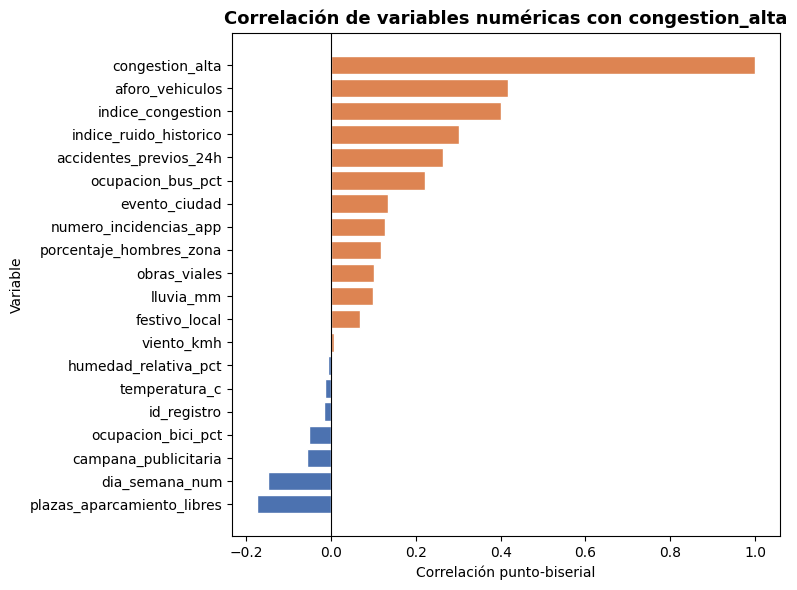

In [18]:
correlaciones = data.corr(numeric_only=True)['congestion_alta'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables numéricas con congestion_alta', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación punto-biserial')
ax.set_ylabel('Variable')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

El gráfico muestra la correlación punto-biserial de cada variable numérica con `congestion_alta`. Las barras naranjas indican correlación positiva (cuando la variable sube, aumenta la probabilidad de congestión alta) y las azules correlación negativa (cuando la variable sube, disminuye la probabilidad de congestión alta).

**Variables más correlacionadas positivamente:**

`aforo_vehiculos` es la variable más correlacionada con el target (0.42), excluyendo `indice_congestion` que como ya vimos no puede usarse como predictor por data leakage. Cuantos más vehículos registra el sensor, más probable es que haya congestión alta. `indice_ruido_historico` (0.30) y `accidentes_previos_24h` (0.26) también muestran una relación positiva relevante. `ocupacion_bus_pct` (0.22) indica que cuando el autobús va lleno, la congestión tiende a ser mayor, probablemente porque refleja una demanda de movilidad elevada en la zona.

**Variables con correlación baja:**

`viento_kmh`, `humedad_relativa_pct` y `temperatura_c` tienen correlaciones prácticamente nulas, lo que sugiere que las condiciones meteorológicas de este tipo no tienen relación lineal con la congestión. Esto no significa que sean inútiles para el modelo, ya que pueden tener relaciones no lineales que la correlación no captura.

**Variables correlacionadas negativamente:**

`plazas_aparcamiento_libres` (-0.17) muestra que cuando hay más plazas libres, hay menos congestión, lo cual es coherente. `dia_semana_num` (-0.15) indica que los días más avanzados de la semana tienden a tener ligeramente menos congestión. `campana_publicitaria` (-0.06) tiene una correlación negativa muy leve que probablemente sea ruido estadístico sin interpretación clara.

**Nota importante:** `id_registro` aparece en el gráfico pero es simplemente el índice de las filas y no debe usarse como predictor.

### Distribución de variables numéricas por clase

Para profundizar en la relación entre cada variable numérica y la variable objetivo, visualizamos la distribución de cada una separada por clase (congestion_alta = 0 y congestion_alta = 1). 

Esto nos permite ver no solo si hay diferencia de media entre clases, como ya vimos con la correlación, sino también si las distribuciones se solapan mucho o poco. Cuanto menos se solapen las curvas de ambas clases, más útil será esa variable para que el modelo distinga entre congestión alta y no congestión. Si las curvas se superponen casi por completo, la variable aportará poco poder discriminativo al modelo.

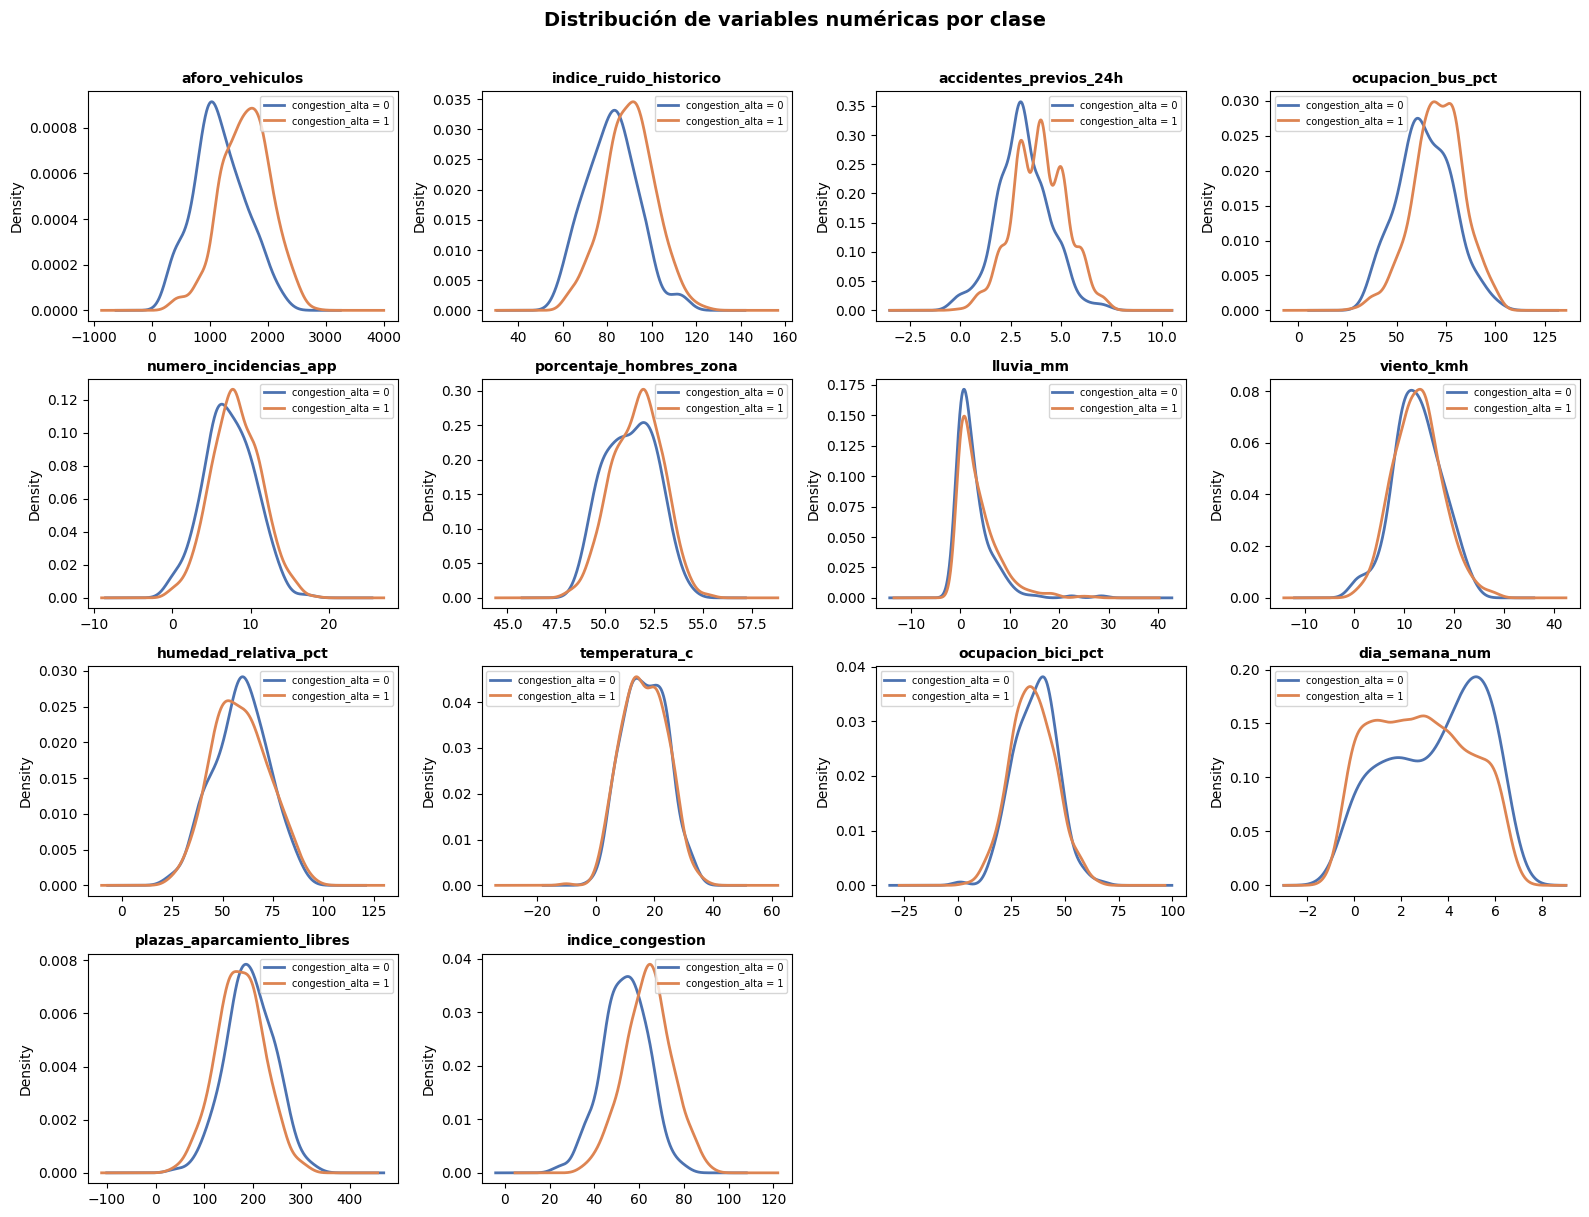

In [19]:
variables_numericas = [
    'aforo_vehiculos', 'indice_ruido_historico', 'accidentes_previos_24h',
    'ocupacion_bus_pct', 'numero_incidencias_app', 'porcentaje_hombres_zona',
    'lluvia_mm', 'viento_kmh', 'humedad_relativa_pct', 'temperatura_c',
    'ocupacion_bici_pct', 'dia_semana_num', 'plazas_aparcamiento_libres','indice_congestion'
]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = data[data['congestion_alta'] == label][var].dropna()
        subset.plot(kind='kde', ax=axes[i], label=f'congestion_alta = {label}', color=color, linewidth=2)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

for j in range(len(variables_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El gráfico de densidades permite visualizar cómo se distribuye cada variable numérica según si hay congestión alta o no. Cuanto menos se solapen las curvas azul y naranja, más poder discriminativo tiene esa variable para el modelo.

**Variables con buena separación entre clases:**

`aforo_vehiculos` muestra las curvas claramente desplazadas entre clases, siendo la variable con mayor poder discriminativo de todas las analizadas. `plazas_aparcamiento_libres` también presenta una separación clara, con la clase sin congestión concentrada en valores más altos de plazas libres, lo cual es coherente. `dia_semana_num` muestra distribuciones distintas entre clases, confirmando que el día de la semana influye en la congestión.

**Variables con separación moderada:**

`accidentes_previos_24h`, `ocupacion_bus_pct` y `numero_incidencias_app` muestran cierto desplazamiento entre curvas aunque con solapamiento considerable. Pueden aportar información útil al modelo aunque no sean tan discriminativas como el aforo.

**Variables con curvas prácticamente idénticas:**

`viento_kmh`, `humedad_relativa_pct` y `temperatura_c` muestran distribuciones casi idénticas para ambas clases, confirmando la baja correlación observada anteriormente. Su aportación al modelo será probablemente limitada.


> **Nota sobre la correlación punto-biserial:** La correlación no es más que una forma de resumir en un solo número la diferencia entre los dos grupos que vemos en el gráfico. Se calcula comparando la media de cada variable en el grupo con congestión alta y en el grupo sin congestión alta, en relación a la variabilidad total de esa variable:
>
> $$r = \frac{\bar{X}_1 - \bar{X}_0}{s} \cdot \sqrt{\frac{n_1 \cdot n_0}{n^2}}$$
>
> Donde $\bar{X}_1$ es la media de la variable en el grupo con congestión alta, $\bar{X}_0$ es la media en el grupo sin congestión, $s$ es la desviación típica global de la variable, $n_1$ y $n_0$ son el número de casos de cada clase y $n$ el total. Si la media del grupo con congestión es muy distinta a la del grupo sin congestión, la correlación será alta. Si las medias son parecidas, la correlación será cercana a cero.

### Relación de variables categóricas con la variable objetivo

Para las variables categóricas no tiene sentido calcular correlación, ya que sus valores son etiquetas y no números con orden. En su lugar, calculamos la tasa de congestión alta por categoría, es decir, qué porcentaje de registros de cada categoría tiene `congestion_alta = 1`.

Si una categoría tiene una tasa muy distinta al resto, significa que esa variable tiene poder discriminativo para el modelo. Si todas las categorías tienen tasas similares, la variable aportará poco.

Las variables que analizamos son `distrito`, `tipo_dia`, `franja_horaria` y `color_semaforo_dominante`. Además incluimos `dia_semana_num` tratándola como categórica, ya que aunque está codificada numéricamente sus valores representan días concretos de la semana y no una magnitud continua, por lo que tiene más sentido analizarla como grupo que como número(como hicimos anteriormente).

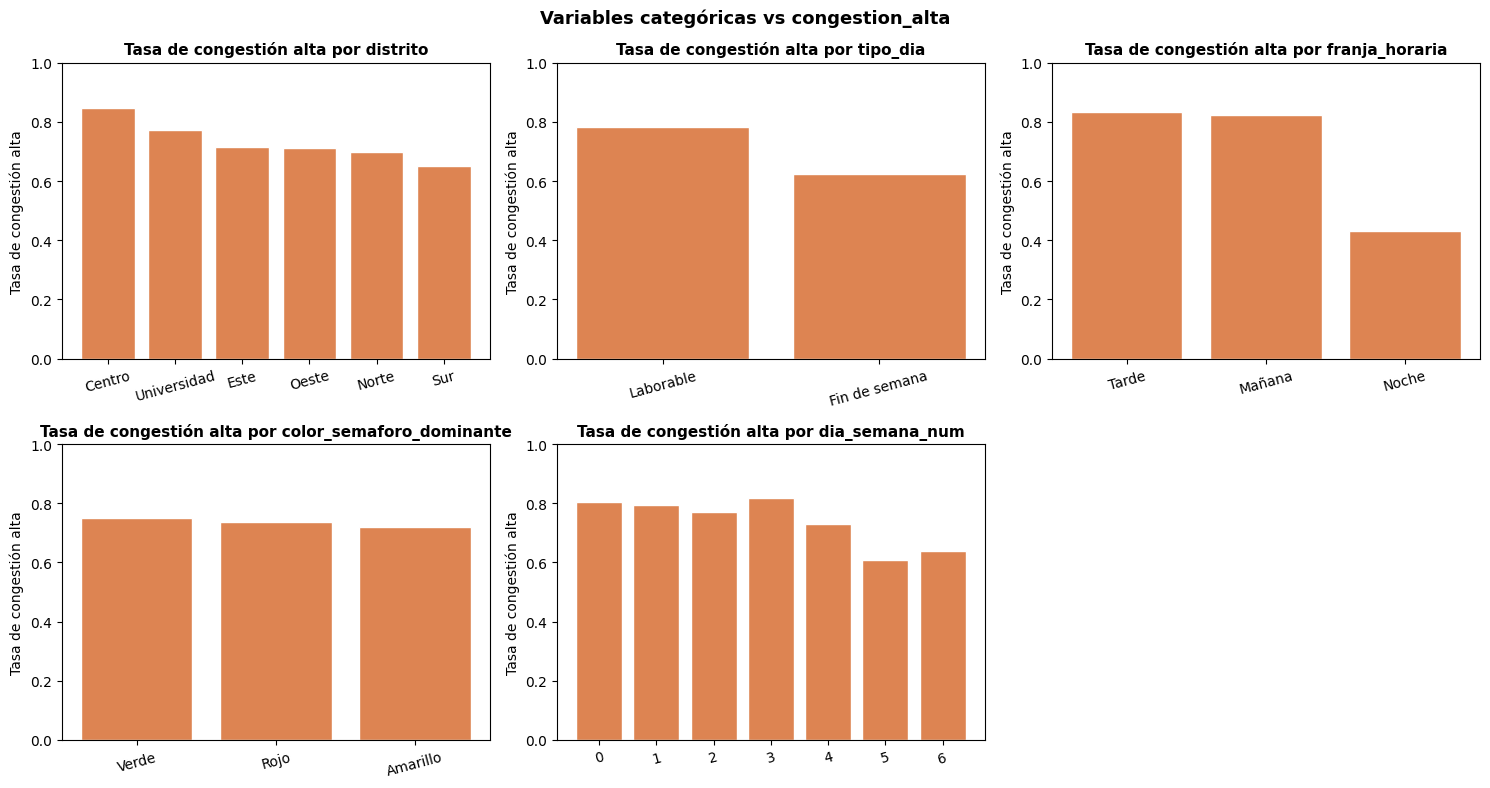

In [20]:
categoricas = ['distrito', 'tipo_dia', 'franja_horaria', 'color_semaforo_dominante', 'dia_semana_num']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    tasa = data.groupby(var)['congestion_alta'].mean().sort_values(ascending=False)
    axes[i].bar(tasa.index, tasa.values, color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Tasa de congestión alta por {var}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de congestión alta')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)
plt.suptitle('Variables categóricas vs congestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Distrito:** El distrito Centro tiene la tasa de congestión alta más elevada (0.85), seguido de Universidad (0.77). El distrito Sur es el menos congestionado (0.65). Hay diferencias relevantes entre distritos, lo que indica que esta variable aportará información útil al modelo.

**Tipo de día:** Los días laborables tienen una tasa de congestión alta del 0.78 frente al 0.63 de los fines de semana. La diferencia es clara y tiene sentido, hay más tráfico entre semana por desplazamientos al trabajo.

**Franja horaria:** Es la variable categórica con mayor poder discriminativo. La tarde y la mañana tienen tasas muy altas (0.83 y 0.82) mientras que la noche cae hasta 0.44. Esto tiene todo el sentido ya que de noche hay mucho menos tráfico.

**Color semáforo dominante:** Las tres categorías (Verde, Rojo y Amarillo) tienen tasas muy similares entre sí, alrededor de 0.72. Esta variable prácticamente no discrimina entre clases y probablemente aporte poco al modelo.

**Día de la semana:** Los días entre semana (0 a 3, lunes a jueves) tienen tasas de congestión alta entre 0.77 y 0.82, mientras que el sábado (5) baja hasta 0.60. El patrón es coherente con lo que vimos en `tipo_dia`. Tratada como categórica resulta más informativa que como numérica continua.

### Relación de variables binarias con la variable objetivo

Las variables binarias solo toman dos valores: 0 (ausencia) y 1 (presencia). Para analizar su relación con `congestion_alta` calculamos la tasa de congestión alta cuando la variable vale 0 y cuando vale 1, y comparamos ambas tasas.

Si la tasa de congestión alta es muy distinta entre el grupo con valor 0 y el grupo con valor 1, la variable tiene poder discriminativo. Si las tasas son similares, la variable aportará poco al modelo.

Las variables binarias que analizamos son `evento_ciudad` (si hay un evento en la ciudad), `obras_viales` (si hay obras en la vía), `festivo_local` (si es festivo local) y `campana_publicitaria` (si hay campaña publicitaria activa en la zona).

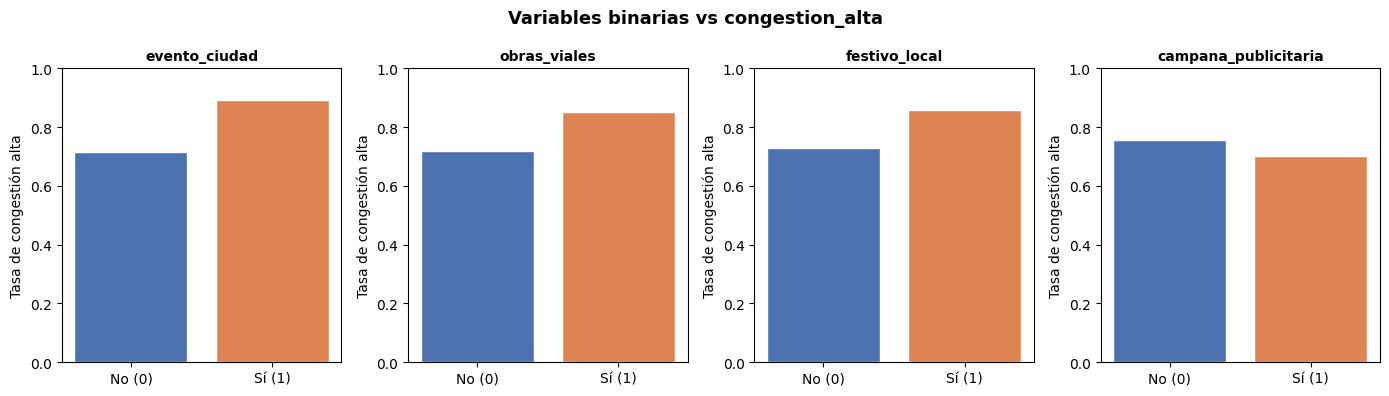

In [21]:
binarias = ['evento_ciudad', 'obras_viales', 'festivo_local', 'campana_publicitaria']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, var in enumerate(binarias):
    tasa = data.groupby(var)['congestion_alta'].mean()
    axes[i].bar(tasa.index.astype(str), tasa.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Tasa de congestión alta')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No (0)', 'Sí (1)'])

plt.suptitle('Variables binarias vs congestion_alta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**evento_ciudad:** Cuando hay un evento en la ciudad la tasa de congestión alta sube hasta 0.90, frente al 0.72 cuando no hay evento. Es la variable binaria con mayor diferencia entre grupos, lo que la convierte en una buena candidata predictora.

**obras_viales:** La presencia de obras viales eleva la tasa de congestión alta hasta 0.85 frente al 0.72 sin obras. Tiene sentido, las obras reducen la capacidad de la vía y generan cuellos de botella.

**festivo_local:** Los días festivos tienen una tasa de congestión alta de 0.86 frente al 0.73 de los días no festivos. Sorprendentemente los festivos tienen más congestión, lo que podría explicarse por eventos, desplazamientos de ocio o concentración de actividad en zonas concretas.

**campana_publicitaria:** Es la única variable binaria con comportamiento inverso. Cuando hay campaña publicitaria la tasa baja ligeramente a 0.70 frente al 0.76 sin campaña. La diferencia es pequeña y probablemente no sea significativa, por lo que esta variable aportará poco al modelo.

### Variable de id_sensor

Aunque `id_sensor` es un identificador, puede ser informativo analizar si hay sensores que registran sistemáticamente más congestión alta que otros, lo que indicaría que su ubicación geográfica es relevante.

La siguiente tabla muestra los 10 sensores con mayor tasa de congestión alta:

In [22]:
resumen_sensor = data.groupby('id_sensor')['congestion_alta'].agg(
    tasa_congestion = 'mean',
    numero_registros_sensor = 'count',
    numero_congestion_alta = 'sum'
)

resumen_sensor['numero_congestion_no_alta'] = resumen_sensor['numero_registros_sensor']-resumen_sensor['numero_congestion_alta']

resumen_sensor.sort_values('tasa_congestion',ascending=False).head(10)

,tasa_congestion,numero_registros_sensor,numero_congestion_alta,numero_congestion_no_alta
id_sensor,,,,
S-037,1.000000,12,12,0
S-014,0.937500,16,15,1
S-009,0.916667,12,11,1
S-016,0.909091,11,10,1
S-004,0.900000,10,9,1
S-019,0.875000,16,14,2
S-031,0.866667,15,13,2
S-036,0.866667,15,13,2
S-012,0.866667,15,13,2


El sensor S-037 registra congestión alta en el 100% de sus registros, lo que sugiere que está ubicado en una zona especialmente conflictiva. Sin embargo, incluir `id_sensor` directamente como predictor tiene dos problemas.

El primero es el overfitting. Con 50 sensores distintos y una media de solo 14 registros por sensor, el modelo podría memorizar qué sensores tienen más congestión en los datos de entrenamiento sin aprender patrones generalizables. Si en producción aparece un sensor nuevo o con pocos registros históricos, el modelo no sabría qué hacer con él.

El segundo es el data leakage. Una alternativa sería crear una variable derivada con la tasa histórica de congestión por sensor, pero esa tasa se calcularía con datos del propio dataset, lo que puede contaminar el modelo si no se hace correctamente separando siempre entrenamiento y test.

Por tanto, `id_sensor` se excluye del modelo. Las variables `distrito` y `franja_horaria` ya capturan implícitamente la información geográfica y temporal que el sensor podría aportar.

### Análisis de la variable fecha

La variable `fecha` no puede usarse directamente como predictor ya que es una cadena de texto con una fecha concreta. Sin embargo, contiene información temporal valiosa que se puede extraer en forma de variables derivadas como el mes, el trimestre o la semana del año.

El objetivo es detectar si hay patrones estacionales en la congestión alta, es decir, si hay meses o épocas del año con más congestión que otras. Si existen esos patrones, tendría sentido crear variables derivadas a partir de `fecha` para incluirlas en el modelo.

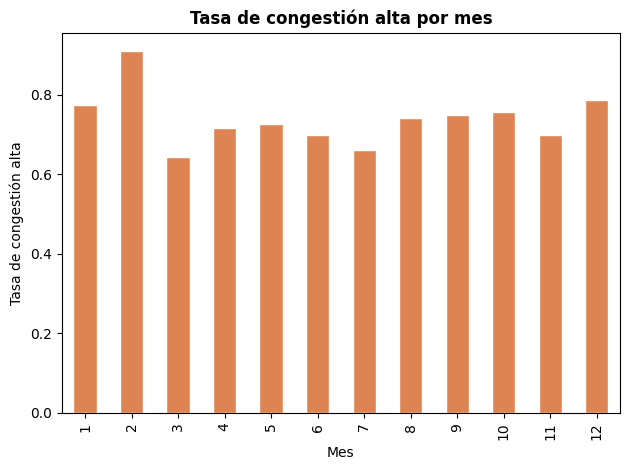

In [23]:
data['fecha']= pd.to_datetime(data['fecha'])
data['mes'] = data['fecha'].dt.month
data.groupby('mes')['congestion_alta'].mean().plot(kind='bar', color='#DD8452', edgecolor='white')
plt.title('Tasa de congestión alta por mes', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de congestión alta')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

El gráfico muestra la tasa de congestión alta por mes. Se observan algunas variaciones pero sin un patrón estacional claro y consistente. Febrero destaca con la tasa más alta (0.90) y marzo con la más baja (0.64), pero el resto de meses se mantiene en un rango bastante estrecho entre 0.65 y 0.78.

La ausencia de un patrón estacional claro sugiere que el mes por sí solo no es un predictor fuerte de la congestión alta. Sin embargo, dado que el dataset solo tiene 720 registros repartidos entre 12 meses, hay pocos registros por mes y las tasas pueden estar influenciadas por el azar más que por patrones reales.

Por tanto, se podría incluir el mes como variable derivada de `fecha` en la fase de preparación de datos, pero con cautela. La variable `fecha` original se descartará del modelo ya que no puede usarse directamente como predictor.

In [24]:
data['año']= data['fecha'].dt.year

data['año'].value_counts() # todos los registros son de 2025

año
2025    720
Name: count, dtype: int64

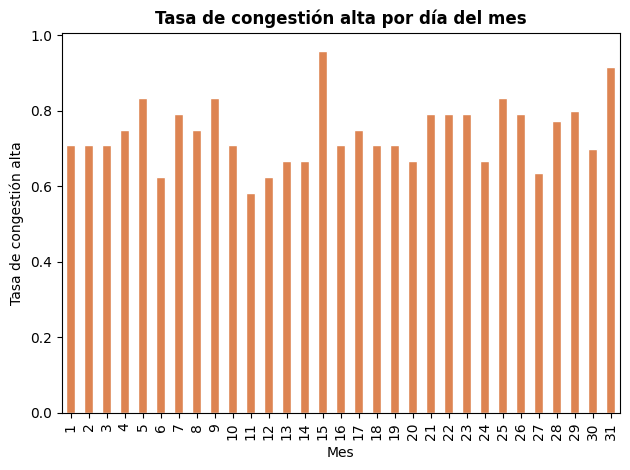

In [25]:
data['dia'] = data['fecha'].dt.day
data.groupby('dia')['congestion_alta'].mean().plot(kind='bar', color='#DD8452', edgecolor='white')
plt.title('Tasa de congestión alta por día del mes', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de congestión alta')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

Analizando la tasa de congestión alta por día del mes tampoco se observa ningún patrón claro. Los valores oscilan aleatoriamente entre 0.59 y 0.95 sin ninguna tendencia identificable. Esto confirma que el día del mes no aporta información predictiva útil y no se creará una variable derivada a partir de él. Solo se extraerá el mes de `fecha` para capturar posible estacionalidad mensual.

### Variables que podrían requerir transformación

Antes de entrenar el modelo es importante analizar si las variables numéricas necesitan algún tipo de transformación. Hay tres aspectos clave a revisar.

El primero son los **rangos y escalas**. Si las variables tienen escalas muy distintas entre sí, como `aforo_vehiculos` que va de 350 a 2785 y `lluvia_mm` que va de 0 a 28, los modelos sensibles a la escala como la regresión logística o los basados en distancias pueden verse afectados. En ese caso se aplica escalado, normalizando todas las variables a un rango común.

El segundo es la **asimetría o skewness**. Si una variable tiene su distribución muy sesgada hacia un lado, con una cola larga, puede beneficiarse de una transformación logarítmica o de raíz cuadrada para aproximarla a una distribución más simétrica y mejorar el rendimiento del modelo.

El tercero son los **outliers**. Valores extremos muy alejados de la media pueden distorsionar el aprendizaje del modelo. Es importante detectarlos y decidir si eliminarlos, capearlos o transformarlos.

A continuación analizamos cada uno de estos aspectos sobre las variables numéricas del dataset.

In [26]:
variables_numericas = [
    'aforo_vehiculos', 'indice_ruido_historico', 'accidentes_previos_24h',
    'ocupacion_bus_pct', 'numero_incidencias_app', 'porcentaje_hombres_zona',
    'lluvia_mm', 'viento_kmh', 'humedad_relativa_pct', 'temperatura_c',
    'ocupacion_bici_pct', 'plazas_aparcamiento_libres'
]

resumen = data[variables_numericas].agg(['min', 'max', 'mean', 'std', 'skew']).T
resumen['rango'] = resumen['max'] - resumen['min']
resumen = resumen[['min', 'max', 'rango', 'mean', 'std', 'skew']].round(2)
print(resumen)

                              min     max   rango     mean     std  skew
aforo_vehiculos             350.0  2785.0  2435.0  1503.36  473.64 -0.18
indice_ruido_historico       58.4   125.0    66.6    88.02   11.89  0.01
accidentes_previos_24h        0.0     7.0     7.0     3.72    1.33  0.03
ocupacion_bus_pct            28.5   100.0    71.5    69.39   13.29 -0.16
numero_incidencias_app        0.0    18.0    18.0     7.96    3.16  0.07
porcentaje_hombres_zona      48.0    55.2     7.2    51.54    1.28 -0.09
lluvia_mm                     0.0    28.5    28.5     3.34    4.04  2.25
viento_kmh                    0.0    28.3    28.3    12.75    4.84  0.16
humedad_relativa_pct         25.0    95.0    70.0    58.93   13.79  0.08
temperatura_c               -10.1    38.0    48.1    16.61    7.44  0.04
ocupacion_bici_pct            1.2    66.9    65.7    35.28   10.26  0.04
plazas_aparcamiento_libres   31.0   327.0   296.0   179.79   49.65  0.00


Las variables tienen rangos muy distintos entre sí. `aforo_vehiculos` tiene un rango de 2.435 (de 350 a 2.785) mientras que `porcentaje_hombres_zona` tiene un rango de solo 7.2 (de 48 a 55.2). Esta diferencia de escala es enorme y afectará directamente a modelos sensibles a la magnitud como la regresión logística o los basados en distancias, que interpretarán `aforo_vehiculos` como mucho más importante simplemente por tener valores más grandes. Por eso todas las variables numéricas deberán escalarse antes de entrenar ese tipo de modelos.

La gran mayoría de variables tienen skewness cercana a 0, lo que indica distribuciones bastante simétricas. La excepción clara es `lluvia_mm` con skewness de 2.25, muy sesgada a la derecha: la mayoría de días llueve poco o nada pero hay episodios puntuales de lluvia intensa que estiran la cola derecha. Es la única candidata clara a transformación logarítmica.

`porcentaje_hombres_zona` tiene una desviación típica de solo 1.28 con una media de 51.54, lo que significa que prácticamente todos los registros tienen valores muy similares entre 48 y 55. Una variable con tan poca variabilidad aportará muy poco al modelo ya que casi no discrimina entre registros.

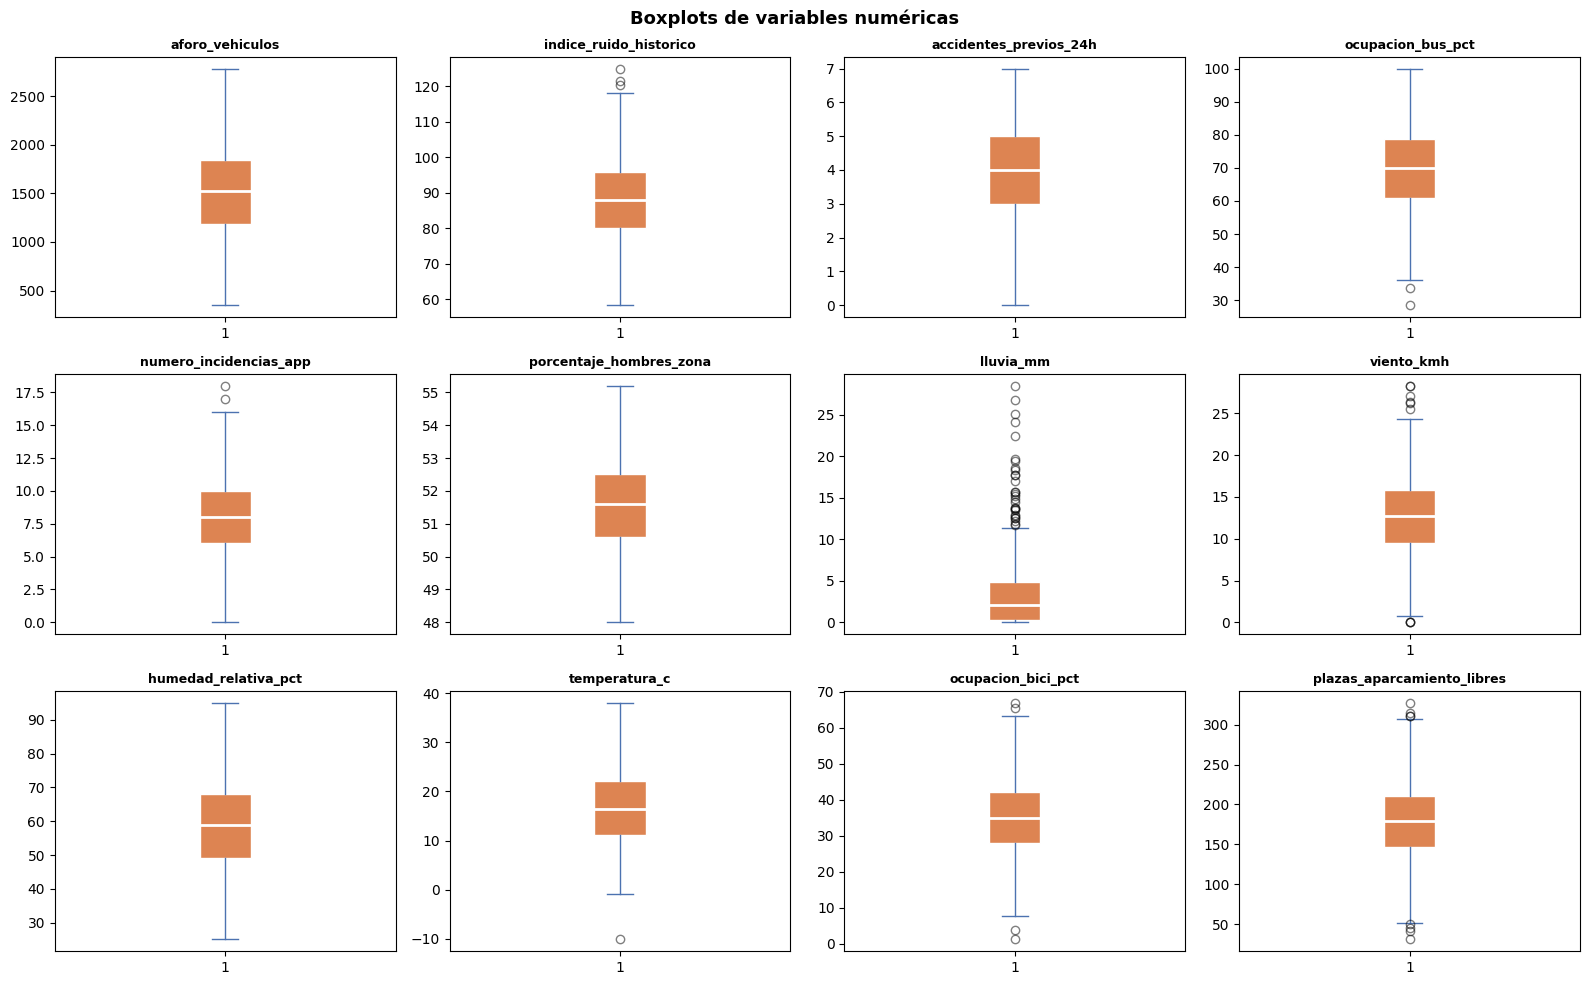

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(data[var].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', color='white'),
                   medianprops=dict(color='white', linewidth=2),
                   whiskerprops=dict(color='#4C72B0'),
                   capprops=dict(color='#4C72B0'),
                   flierprops=dict(marker='o', color='#4C72B0', alpha=0.5))
    axes[i].set_title(var, fontsize=9, fontweight='bold')

plt.suptitle('Boxplots de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Los boxplots permiten visualizar la dispersión, la mediana y los outliers de cada variable numérica. Los puntos que aparecen fuera de los bigotes son valores atípicos.

**Variables con outliers destacables:**

`lluvia_mm` es la variable con más outliers visibles, con numerosos puntos por encima de 15mm. Esto confirma el skewness de 2.25 que vimos antes: la mayoría de registros tienen lluvia baja o nula pero hay episodios puntuales de lluvia intensa. Es la candidata más clara a transformación logarítmica.

`indice_ruido_historico` tiene dos puntos por encima de 115, claramente alejados del resto de valores que se concentran entre 60 y 110. Podrían ser outliers reales o errores de medición.

`numero_incidencias_app` tiene un punto en 17-18 incidencias, bastante por encima del rango habitual de 0 a 12. `ocupacion_bici_pct` y `plazas_aparcamiento_libres` también muestran algún punto aislado en los extremos.

`temperatura_c` tiene un valor mínimo de -10.1 que aparece como outlier inferior, coherente con una ola de frío puntual.

**Variables sin outliers relevantes:**

`aforo_vehiculos`, `humedad_relativa_pct`, `viento_kmh`, `ocupacion_bus_pct` y `accidentes_previos_24h` muestran distribuciones limpias sin valores atípicos destacables.

**Variables con rango muy estrecho:**

`porcentaje_hombres_zona` tiene un rango de solo 7.2 puntos (48 a 55.2) y una caja muy compacta. Prácticamente no varía entre registros, lo que sugiere que esta variable aportará muy poco poder predictivo al modelo.


`lluvia_mm` necesita transformación logarítmica por su fuerte asimetría. Todas las variables numéricas necesitarán escalado antes de entrenar modelos sensibles a la magnitud como la regresión logística. Los outliers detectados son en su mayoría valores extremos pero plausibles, por lo que no se eliminarán sino que se caparán si es necesario en la fase de preparación.

### Act 2: comprensión del dataset

#### Variable objetivo

| Variable | Justificación |
|---|---|
| `congestion_alta` | Variable binaria (0/1) que indica si hay congestión alta. Es la variable que el modelo debe predecir. |


#### Variables candidatas a predictoras

| Variable | Justificación |
|---|---|
| `aforo_vehiculos` | Mayor correlación con el target (0.42). Cuantos más vehículos, más congestión. |
| `indice_ruido_historico` | Correlación moderada (0.30). Las zonas más ruidosas tienden a tener más congestión. |
| `accidentes_previos_24h` | Correlación moderada (0.26). Más accidentes previos, más congestión. |
| `ocupacion_bus_pct` | Correlación moderada (0.22). Refleja demanda de movilidad elevada en la zona. |
| `plazas_aparcamiento_libres` | Correlación negativa (-0.17). Más plazas libres, menos congestión. |
| `dia_semana_num` | Correlación negativa (-0.15). Los días de fin de semana tienen menos congestión. |
| `evento_ciudad` | Mayor diferencia entre grupos (0.72 sin evento vs 0.90 con evento). |
| `obras_viales` | Diferencia clara entre grupos (0.72 sin obras vs 0.85 con obras). |
| `festivo_local` | Diferencia entre grupos (0.73 sin festivo vs 0.86 con festivo). |
| `franja_horaria` | Gran diferencia entre franjas. Noche (0.44) vs mañana y tarde (0.82-0.83). |
| `tipo_dia` | Diferencia clara. Laborable (0.78) vs fin de semana (0.63). |
| `distrito` | Diferencia entre distritos. Centro (0.85) vs Sur (0.65). |
| `numero_incidencias_app` | Correlación baja pero positiva (0.13). Más incidencias, más congestión. |
| `lluvia_mm` | Correlación baja (0.10) pero puede tener relación no lineal con la congestión. |
| `ocupacion_bici_pct` | Correlación negativa leve (-0.05). Más uso de bici, ligeramente menos congestión. |
| `mes` | Variable derivada de `fecha`. Puede capturar estacionalidad. |


#### Posibles variables no relevantes

| Variable | Justificación |
|---|---|
| `id_registro` | Índice de fila sin información predictiva. |
| `id_sensor` | Identificador con 50 valores distintos y pocos registros por sensor. Su inclusión causaría overfitting. |
| `fecha` | No puede usarse directamente. Se puede derivar el mes. |
| `color_semaforo_dominante` | Tasas muy similares entre categorías (0.71-0.75). Prácticamente no discrimina. |
| `campana_publicitaria` | Correlación muy baja (-0.06) y diferencia entre grupos mínima. |
| `viento_kmh` | Correlación prácticamente nula (0.006). |
| `humedad_relativa_pct` | Correlación prácticamente nula (-0.007). |
| `temperatura_c` | Correlación prácticamente nula (-0.013). |
| `porcentaje_hombres_zona` | Rango de solo 7.2 puntos y desviación típica de 1.28. Prácticamente no varía entre registros. |


#### Variables que pueden causar sesgo

| Variable | Justificación |
|---|---|
| `indice_congestion` | Está directamente relacionada con `congestion_alta`. Usarla como predictor causaría data leakage: el modelo aprendería a predecir el target usando información que en producción real ya implica conocer la respuesta. Debe excluirse. |
| `porcentaje_hombres_zona` | Variable demográfica de género que no tiene justificación causal clara con la congestión. Su inclusión podría introducir sesgo sin mejorar el modelo. |


#### Variables que requieren transformación

| Variable | Transformación necesaria | Justificación |
|---|---|---|
| `lluvia_mm` | Transformación logarítmica | Skewness de 2.25, distribución muy sesgada a la derecha con muchos valores cercanos a 0 y episodios puntuales de lluvia intensa. |
| `aforo_vehiculos` | Escalado | Rango de 2.435, mucho mayor que el resto de variables. |
| `plazas_aparcamiento_libres` | Escalado | Rango de 296, escala muy distinta al resto. |
| `indice_ruido_historico` | Escalado | Rango de 66.6 con outliers por encima de 115. |
| `ocupacion_bus_pct` | Escalado | Rango de 71.5. |
| `humedad_relativa_pct` | Escalado | Rango de 70. |
| `temperatura_c` | Escalado | Rango de 48.1 con valor mínimo de -10.1. |
| `distrito` | Codificación One-Hot Encoding | Variable categórica con 6 categorías sin orden natural. |
| `franja_horaria` | Codificación One-Hot Encoding | Variable categórica con 3 categorías sin orden natural. |
| `tipo_dia` | Codificación binaria | Variable categórica con solo 2 categorías (Laborable/Fin de semana). |
| `color_semaforo_dominante` | Codificación One-Hot Encoding | Variable categórica con 3 categorías sin orden natural. Aunque probablemente se descarte por ser poco relevante. |
| `dia_semana_num` | Ya codificada numéricamente | Podría tratarse como categórica con One-Hot Encoding si se quiere evitar que el modelo asuma orden entre días. |
| `mes` | Codificación cíclica o One-Hot Encoding | Variable derivada de fecha. Al ser cíclica (enero sigue a diciembre) podría codificarse con seno y coseno. |

## Preparación de los datos

En esta sección preparamos el dataset para poder entrenar los modelos. A partir del análisis exploratorio del Act 2 ya sabemos qué variables incluir, cuáles descartar y qué transformaciones necesitan a priori. El objetivo es dejar el dataset limpio y listo para el entrenamiento.

Los pasos que seguiremos son los siguientes. Primero eliminaremos las variables que hemos decidido no usar. Segundo trataremos los valores ausentes de las variables que los tienen. Tercero crearemos variables derivadas como el mes a partir de fecha. Cuarto aplicaremos la transformación logarítmica a lluvia_mm. Quinto codificaremos las variables categóricas. Sexto escalaremos las variables numéricas. Y por último realizaremos la partición entre datos de entrenamiento y datos de prueba.

### Paso 1: Eliminación de variables claras

En este paso eliminamos únicamente las variables que tienen razones objetivas e irrefutables para ser descartadas, independientemente del modelo que se vaya a entrenar. Las variables con correlación baja como `color_semaforo_dominante` o `campana_publicitaria` no se eliminan aquí — se dejará que el propio modelo determine su importancia mediante las métricas de importancia de variables en fases posteriores.

Las variables eliminadas y su justificación son las siguientes:

`id_registro` es un índice de fila sin ninguna información predictiva, su único papel es identificar cada registro de forma única.

`id_sensor` es un identificador con 50 valores distintos y pocos registros por sensor (media de 14 registros), lo que causaría overfitting ya que el modelo memorizaría qué sensores tienen más congestión en entrenamiento sin aprender patrones generalizables.

`fecha` no puede usarse directamente como predictor. Se sustituye por la variable derivada `mes` que captura posible estacionalidad mensual.

`año` y `dia` son variables creadas durante la exploración inicial. `año` no discrimina porque todos los registros son de 2025, y el análisis por día del mes mostró que no existe ningún patrón claro en la tasa de congestión alta.

In [28]:
data.columns

Index(['id_registro', 'fecha', 'dia_semana_num', 'distrito', 'tipo_dia',
       'franja_horaria', 'id_sensor', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'color_semaforo_dominante', 'campana_publicitaria',
       'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta',
       'mes', 'año', 'dia'],
      dtype='str')

In [29]:
variables_eliminar = [
    'id_registro',
    'id_sensor', 
    'fecha',
    'año',
    'dia'
]

data_clean = data.drop(columns=variables_eliminar)
print(f"Variables antes de eliminar", data.shape[1])
print(f"Variables al eliminar", data_clean.shape[1])
print(data_clean.columns.tolist())

Variables antes de eliminar 29
Variables al eliminar 24
['dia_semana_num', 'distrito', 'tipo_dia', 'franja_horaria', 'temperatura_c', 'humedad_relativa_pct', 'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales', 'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h', 'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct', 'numero_incidencias_app', 'indice_ruido_historico', 'color_semaforo_dominante', 'campana_publicitaria', 'porcentaje_hombres_zona', 'indice_congestion', 'congestion_alta', 'mes']


### Paso 2: Eliminación por data leakage

Se elimina `indice_congestion` porque está directamente relacionada con la variable objetivo `congestion_alta`. Es muy probable que el target se haya derivado de esta variable, por lo que usarla como predictor causaría data leakage: el modelo aprendería a predecir la respuesta usando información que en producción real ya implica conocerla, generando resultados artificialmente buenos que no se reproducirían fuera del dataset.

In [30]:
data_clean = data_clean.drop(columns= 'indice_congestion')

print(f"Variables al eliminar", data_clean.shape[1])

Variables al eliminar 23


### Paso 3: Eliminación por baja variabilidad y sesgo potencial

`porcentaje_hombres_zona` se elimina por dos motivos independientes. Técnicamente, su rango de variación es de solo 7.2 puntos (mín. 48.0, máx. 55.2) con una desviación típica de 1.28 sobre una media de 51.54, lo que la convierte en una variable prácticamente constante que no aporta información discriminante al modelo. Adicionalmente, no existe justificación causal entre la composición de género de una zona y la probabilidad de congestión, por lo que su inclusión podría introducir sesgo sin ningún 
beneficio predictivo.

In [31]:
data_clean['porcentaje_hombres_zona'].describe()

count    720.000000
mean      51.535833
std        1.278394
min       48.000000
25%       50.600000
50%       51.600000
75%       52.500000
max       55.200000
Name: porcentaje_hombres_zona, dtype: float64

In [32]:
data_clean = data_clean.drop(columns=['porcentaje_hombres_zona'])
print(f"Variables tras eliminar baja variabilidad: {data_clean.shape[1]}")

Variables tras eliminar baja variabilidad: 22


> Es importante destacar que aunque en el análisis exploratorio identificamos variables con correlación baja o tasas de congestión similares entre categorías, como `color_semaforo_dominante`, `campana_publicitaria`, `viento_kmh`, `humedad_relativa_pct` o `temperatura_c`, hemos decidido no eliminarlas en esta fase. La correlación lineal y el análisis univariante tienen limitaciones: una variable puede parecer poco relevante de forma individual pero aportar información útil al modelo en combinación con otras variables, o tener relaciones no lineales con el target que estos análisis no capturan. Dejaremos que el propio modelo determine su importancia en fases posteriores mediante las métricas de importancia de variables.

### Paso 4: Tratamiento de valores ausentes

Antes de entrenar cualquier modelo es necesario tratar los valores ausentes del dataset. En el análisis exploratorio observamos que varias variables numéricas tienen registros con valores nulos. En este paso identificamos exactamente cuántos nulos hay en cada variable y decidimos cómo tratarlos.

In [33]:
nulos = data_clean.isna().sum().sort_values(ascending=False) # cantidad de valores nulos por variable

In [34]:
nulos[nulos>0] # recordatorio: sobre la misma boolean mask

lluvia_mm                     10
distrito                       9
franja_horaria                 9
temperatura_c                  7
ocupacion_bus_pct              5
accidentes_previos_24h         5
humedad_relativa_pct           4
numero_incidencias_app         4
indice_ruido_historico         3
viento_kmh                     3
plazas_aparcamiento_libres     2
ocupacion_bici_pct             2
dtype: int64

Primero se tiene que analizar que tipo de valores nulos son, y la razon por la que existen estos valores nulos. De esta manera se decide como tratar con ellos siempre, ¿son aleatorios o sistemáticos?

In [35]:
# calculamos antes de empezar a tomar decisiones porcentajes sobre el total
(data_clean.isna().mean() * 100)[(data_clean.isna().mean() * 100)>0]

distrito                      1.250000
franja_horaria                1.250000
temperatura_c                 0.972222
humedad_relativa_pct          0.555556
lluvia_mm                     1.388889
viento_kmh                    0.416667
accidentes_previos_24h        0.694444
ocupacion_bus_pct             0.694444
plazas_aparcamiento_libres    0.277778
ocupacion_bici_pct            0.277778
numero_incidencias_app        0.555556
indice_ruido_historico        0.416667
dtype: float64

#### Registros nulos en la variable lluvia_mm

Hay 10 nulos en esta variable que corresponden a un 1.39% del dataset total. Las razones tras estos valores nulos pueden ser diversas. Tratamos de entender cual es más probable.

In [36]:
data_clean['lluvia_mm'].isna().mean()*100 # porcentaje de nulos respecto al total

np.float64(1.3888888888888888)

In [37]:
nulos_lluvia = data_clean[data_clean['lluvia_mm'].isna()]

In [38]:
nulos_lluvia.info() # cuando la lluvia es nula no hay otra variable que tb sea nula-> descartamos caso de nulidad por otra variable

<class 'pandas.DataFrame'>
Index: 10 entries, 16 to 690
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              10 non-null     int64  
 1   distrito                    10 non-null     str    
 2   tipo_dia                    10 non-null     str    
 3   franja_horaria              10 non-null     str    
 4   temperatura_c               10 non-null     float64
 5   humedad_relativa_pct        10 non-null     float64
 6   lluvia_mm                   0 non-null      float64
 7   viento_kmh                  10 non-null     float64
 8   evento_ciudad               10 non-null     int64  
 9   obras_viales                10 non-null     int64  
 10  festivo_local               10 non-null     int64  
 11  aforo_vehiculos             10 non-null     int64  
 12  accidentes_previos_24h      10 non-null     float64
 13  ocupacion_bus_pct           10 non-null     float64

In [39]:
print(f"Registros con lluvia_mm = 0: {(data_clean['lluvia_mm'] == 0).sum()}")
print(f"Registros con lluvia_mm > 0: {(data_clean['lluvia_mm'] > 0).sum()}")
print(f"Registros con lluvia_mm nula: {data_clean['lluvia_mm'].isna().sum()}")
print(f"\nMediana de lluvia_mm: {data_clean['lluvia_mm'].median()}")
print(f"Media de lluvia_mm: {data_clean['lluvia_mm'].mean().round(2)}")

Registros con lluvia_mm = 0: 140
Registros con lluvia_mm > 0: 570
Registros con lluvia_mm nula: 10

Mediana de lluvia_mm: 2.1
Media de lluvia_mm: 3.34


In [40]:
data_clean['lluvia_mm'].describe() # distribucion de lluvia en el dataset 

count    710.000000
mean       3.344366
std        4.044703
min        0.000000
25%        0.300000
50%        2.100000
75%        4.800000
max       28.500000
Name: lluvia_mm, dtype: float64

Los 140 registros con lluvia igual a 0 confirman que cuando no llueve el sensor registra explícitamente 0, no un valor nulo. Por tanto los 10 nulos no representan días sin lluvia sino fallos puntuales del sensor o errores en la recogida de datos.

Dado que son solo el 1.39% del total y que la distribución de `lluvia_mm` está fuertemente sesgada a la derecha (skewness 2.25), se imputa con la mediana (2.1mm) en lugar de la media (3.34mm), ya que la mediana es más robusta ante la asimetría y los valores extremos.

In [41]:
data_clean['lluvia_mm'].median() # vamos a imputar los 10 nulos con este valor 

np.float64(2.1)

In [42]:
data_clean['lluvia_mm'] = data_clean['lluvia_mm'].fillna(data_clean['lluvia_mm'].median())

print(f"Nulos restantes en lluvia_mm: {data_clean['lluvia_mm'].isna().sum()}")

Nulos restantes en lluvia_mm: 0


#### Registros nulos en la variable franja_horaria y distrito

Hay 9 nulos en franja horaria que corresponden a un 1.25% de registros del total. De la misma forma se analiza la razón.

In [43]:
data_clean['franja_horaria'].unique() # recordamos valores q tomaba

<StringArray>
['Mañana', 'Tarde', nan, 'Noche']
Length: 4, dtype: str

In [44]:
data_clean['franja_horaria'].isna().sum(), data_clean['franja_horaria'].isna().mean()*100 # es la misma cantidad y mismo porcentaje en distrito

(np.int64(9), np.float64(1.25))

In [45]:
nulos_franja_horaria = data_clean[data_clean['franja_horaria'].isna()]

In [46]:
nulos_franja_horaria.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 8 to 447
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              9 non-null      int64  
 1   distrito                    9 non-null      str    
 2   tipo_dia                    9 non-null      str    
 3   franja_horaria              0 non-null      str    
 4   temperatura_c               9 non-null      float64
 5   humedad_relativa_pct        9 non-null      float64
 6   lluvia_mm                   9 non-null      float64
 7   viento_kmh                  8 non-null      float64
 8   evento_ciudad               9 non-null      int64  
 9   obras_viales                9 non-null      int64  
 10  festivo_local               9 non-null      int64  
 11  aforo_vehiculos             9 non-null      int64  
 12  accidentes_previos_24h      9 non-null      float64
 13  ocupacion_bus_pct           9 non-null      float64
 

Al analizar estos registros se observa que a la par existen nulos en `viento_kmh` y `ocupacion_bici_pct`, concretamente un registro con nulo en viento y otro con nulo en ocupación de bici. De nuevo los valores nulos no parecen depender del valor de ninguna otra variable ni seguir un patrón claro, apuntando a fallos puntuales en la recogida de datos.

Al tratarse `franja_horaria` de una variable categórica, no tiene sentido imputar con media o mediana. Las opciones son eliminar los 9 registros afectados o imputar con la moda, es decir, con la categoría más frecuente. Dado que son solo el 1.25% del total, eliminar esas filas es la opción más limpia y segura ya que evita introducir ruido artificialmente en una variable tan relevante para el modelo, que como vimos en el análisis exploratorio es una de las más discriminativas.

In [47]:
nulos_franja_horaria[(nulos_franja_horaria['ocupacion_bici_pct'].isna()) | (nulos_franja_horaria['viento_kmh'].isna())] 
# era para ver si los nulos estaban relacionados entre si-> no parece

,dia_semana_num,distrito,tipo_dia,franja_horaria,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,evento_ciudad,obras_viales,...,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,color_semaforo_dominante,campana_publicitaria,congestion_alta,mes
101,3,Norte,Laborable,NaN,21.8,47.0,2.3,10.3,0,1,...,2.0,66.9,153.0,NaN,16.0,89.1,Rojo,0,1,2
329,5,Oeste,Fin de semana,NaN,19.6,74.0,9.4,NaN,0,0,...,2.0,61.5,234.0,49.1,4.0,65.5,Amarillo,0,0,6


> Duda más normal en este punto: ¿Por qué imputar lluvia pero en este caso franja horaria con la moda no? franja_horaria es categórica: sus valores son etiquetas (Mañana, Tarde, Noche). La moda sería imputar todos los nulos con "Tarde" por ejemplo, pero eso introduce información falsa en una variable muy discriminativa. Si esos 9 registros son en realidad de noche y los imputamos como tarde, el modelo aprende mal. Con tan pocos registros es más limpio eliminarlos. En cambio, lluvia_mm es numérica: la mediana es un valor representativo y plausible, no introduce información falsa. En variables categóricas el error de imputación es binario, o aciertas la categoría correcta o te equivocas completamente. En variables numéricas hay un gradiente ya que puedes estar más o menos cerca del valor real, y la mediana es una aproximación razonable que introduce poco error.


In [48]:
data_clean = data_clean[data_clean['franja_horaria'].notna()]  # eliminamos los nulos en franja horaria

Hay 9 nulos en `distrito` que corresponden a un 1.25% del total como se vio al principio. Los registros afectados tienen todas las demás variables completas, apuntando de nuevo a un fallo puntual en la recogida de datos. Al ser `distrito` una variable categórica muy discriminativa (vimos en el análisis exploratorio que la tasa de congestión varía entre 0.65 en Sur y 0.85 en Centro), imputar con la moda asignaría el mismo distrito a todos los registros sin garantía de que sea el correcto. Se eliminan las filas afectadas.

In [49]:
data_clean['distrito'].unique()

<StringArray>
['Centro', 'Este', 'Universidad', 'Sur', 'Oeste', 'Norte', nan]
Length: 7, dtype: str

In [50]:
nulos_distrito = data_clean[data_clean['distrito'].isna()]

In [51]:
nulos_distrito.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 32 to 670
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              9 non-null      int64  
 1   distrito                    0 non-null      str    
 2   tipo_dia                    9 non-null      str    
 3   franja_horaria              9 non-null      str    
 4   temperatura_c               9 non-null      float64
 5   humedad_relativa_pct        9 non-null      float64
 6   lluvia_mm                   9 non-null      float64
 7   viento_kmh                  9 non-null      float64
 8   evento_ciudad               9 non-null      int64  
 9   obras_viales                9 non-null      int64  
 10  festivo_local               9 non-null      int64  
 11  aforo_vehiculos             9 non-null      int64  
 12  accidentes_previos_24h      9 non-null      float64
 13  ocupacion_bus_pct           9 non-null      float64


In [52]:
# solucion análoga a la otra categórica y con la misma razón que antes
data_clean = data_clean[data_clean['distrito'].notna()]

#### Registros nulos en el resto de variables numéricas

Para el resto de variables numéricas con valores ausentes (`temperatura_c`, `humedad_relativa_pct`, `viento_kmh`, `accidentes_previos_24h`, `ocupacion_bus_pct`, `plazas_aparcamiento_libres`, `ocupacion_bici_pct`, `numero_incidencias_app` e `indice_ruido_historico`) se imputa con la **media** en todos los casos. La comparación entre media y mediana de cada variable muestra diferencias mínimas (inferiores a 0.5 unidades en todos los casos), lo que indica distribuciones simétricas sin valores extremos que distorsionen la media. A diferencia de `lluvia_mm`, donde la diferencia entre media (3.34) y mediana (2.1) reflejaba una asimetría clara provocada por episodios puntuales de lluvia intensa, en estas variables la media es un valor representativo del registro típico y por tanto una imputación adecuada.

In [53]:
variables_num = [
    'temperatura_c', 'humedad_relativa_pct', 'viento_kmh',
    'accidentes_previos_24h', 'ocupacion_bus_pct', 'plazas_aparcamiento_libres',
    'ocupacion_bici_pct', 'numero_incidencias_app', 'indice_ruido_historico'
]

data_clean[variables_num].describe()

,temperatura_c,humedad_relativa_pct,viento_kmh,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico
count,695.000000,698.000000,700.000000,697.000000,697.000000,700.000000,701.000000,698.000000,699.000000
mean,16.567194,58.938395,12.765000,3.741750,69.376040,179.294286,35.281027,7.971347,88.124177
std,7.456865,13.605022,4.819288,1.328033,13.389086,49.508881,10.313809,3.092414,11.816628
min,-10.100000,25.000000,0.000000,0.000000,28.500000,31.000000,1.200000,0.000000,58.400000
25%,11.000000,49.000000,9.500000,3.000000,60.700000,147.000000,28.000000,6.000000,80.350000
50%,16.400000,59.000000,12.700000,4.000000,69.900000,179.000000,35.000000,8.000000,88.300000
75%,22.200000,68.000000,15.800000,5.000000,78.800000,210.250000,42.200000,10.000000,96.100000
max,38.000000,95.000000,28.300000,7.000000,100.000000,327.000000,66.900000,18.000000,125.000000


In [54]:
for col in variables_num:
    print("Media variable", col, ":", data_clean[col].mean())
    data_clean[col]= data_clean[col].fillna(data_clean[col].mean()) # sustituir 

print(data_clean[variables_num].isna().sum())

Media variable temperatura_c : 16.567194244604316
Media variable humedad_relativa_pct : 58.938395415472776
Media variable viento_kmh : 12.765
Media variable accidentes_previos_24h : 3.7417503586800573
Media variable ocupacion_bus_pct : 69.37604017216644
Media variable plazas_aparcamiento_libres : 179.2942857142857
Media variable ocupacion_bici_pct : 35.281027104136946
Media variable numero_incidencias_app : 7.97134670487106
Media variable indice_ruido_historico : 88.1241773962804
temperatura_c                 0
humedad_relativa_pct          0
viento_kmh                    0
accidentes_previos_24h        0
ocupacion_bus_pct             0
plazas_aparcamiento_libres    0
ocupacion_bici_pct            0
numero_incidencias_app        0
indice_ruido_historico        0
dtype: int64


In [55]:
# Guardamos una copia del dataset antes de codificar para usar con CatBoost,
# que maneja las variables categóricas de forma nativa sin necesidad de 
# One-Hot Encoding. Usamos .copy() para evitar que los cambios posteriores
# afecten al dataset original.
data_min = data_clean.copy()

### Paso 5: Codificación de variables categóricas

In [56]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 702 entries, 0 to 719
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dia_semana_num              702 non-null    int64  
 1   distrito                    702 non-null    str    
 2   tipo_dia                    702 non-null    str    
 3   franja_horaria              702 non-null    str    
 4   temperatura_c               702 non-null    float64
 5   humedad_relativa_pct        702 non-null    float64
 6   lluvia_mm                   702 non-null    float64
 7   viento_kmh                  702 non-null    float64
 8   evento_ciudad               702 non-null    int64  
 9   obras_viales                702 non-null    int64  
 10  festivo_local               702 non-null    int64  
 11  aforo_vehiculos             702 non-null    int64  
 12  accidentes_previos_24h      702 non-null    float64
 13  ocupacion_bus_pct           702 non-null    float64

#### Codificación de distrito

`distrito` es una variable nominal con 6 categorías sin orden natural entre 
ellas (Centro, Este, Norte, Oeste, Sur, Universidad). Se aplica One-Hot 
Encoding, que crea una columna binaria por cada categoría. Para evitar 
multicolinealidad se elimina una categoría de referencia con `drop_first=True`, 
resultando en 5 columnas nuevas que sustituyen a la variable original.

<BarContainer object of 6 artists>

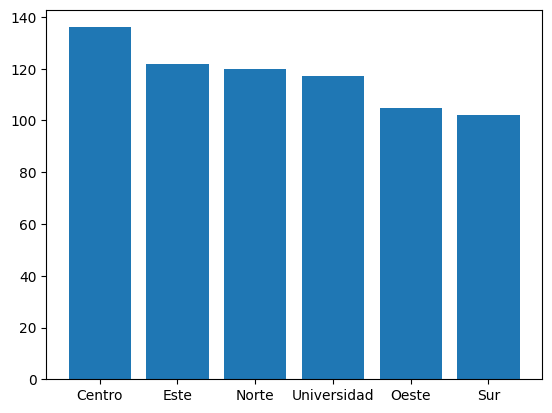

In [57]:
data_clean['distrito'].value_counts()

plt.bar((data_clean['distrito'].value_counts()).index, (data_clean['distrito'].value_counts()).values)

In [58]:
# one hot encoding 
distrito_dummies = pd.get_dummies(data_clean['distrito'], drop_first= True, prefix= 'distrito')
data_clean = pd.concat([data_clean,distrito_dummies], axis=1)
data_clean = data_clean.drop(columns=['distrito'])

#### Codificación de franja horaria

`franja_horaria` es una variable nominal con 3 categorías sin orden natural 
entre ellas (Mañana, Tarde, Noche). Aunque podría argumentarse un orden 
temporal, el modelo no debe asumir que Noche es "más" que Tarde en ningún 
sentido numérico. Se aplica One-Hot Encoding con `drop_first=True`, 
resultando en 2 columnas nuevas que sustituyen a la variable original.

In [59]:
data_clean['franja_horaria'].value_counts()

franja_horaria
Tarde     276
Mañana    269
Noche     157
Name: count, dtype: int64

In [60]:
data_clean = pd.concat([data_clean, pd.get_dummies(data_clean['franja_horaria'], prefix= "franja_horaria", drop_first=True)], axis=1)

data_clean = data_clean.drop(columns= 'franja_horaria')

In [61]:
data_clean

,dia_semana_num,tipo_dia,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,evento_ciudad,obras_viales,festivo_local,aforo_vehiculos,...,campana_publicitaria,congestion_alta,mes,distrito_Este,distrito_Norte,distrito_Oeste,distrito_Sur,distrito_Universidad,franja_horaria_Noche,franja_horaria_Tarde
0,2,Laborable,14.1,61.0,3.5,14.5,0,0,0,1648,...,0,1,1,False,False,False,False,False,False,False
1,2,Laborable,12.6,54.0,12.9,10.7,0,0,0,2279,...,0,1,1,False,False,False,False,False,False,False
2,3,Laborable,22.0,39.0,2.8,9.8,0,0,0,2150,...,1,0,1,True,False,False,False,False,False,True
3,3,Laborable,22.6,49.0,0.4,18.2,0,0,1,2552,...,0,1,1,False,False,False,False,True,False,False
4,4,Laborable,19.3,44.0,3.6,16.8,0,1,0,2151,...,0,1,1,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2,Laborable,6.8,63.0,6.3,5.9,0,0,0,1710,...,1,1,12,False,True,False,False,False,False,False
716,3,Laborable,14.2,51.0,8.4,18.2,0,0,0,1491,...,0,1,12,False,True,False,False,False,False,False
717,3,Laborable,12.7,49.0,0.0,10.9,0,0,0,1573,...,0,1,12,False,True,False,False,False,False,True
718,4,Laborable,12.9,69.0,4.8,12.2,1,0,0,2361,...,1,1,12,False,False,False,False,False,False,True


#### Codificación de `color_semaforo_dominante`

`color_semaforo_dominante` es una variable nominal con 3 categorías sin 
orden natural entre ellas (Verde, Rojo, Amarillo). Se aplica One-Hot 
Encoding con `drop_first=True`, resultando en 2 columnas nuevas que 
sustituyen a la variable original.

<BarContainer object of 3 artists>

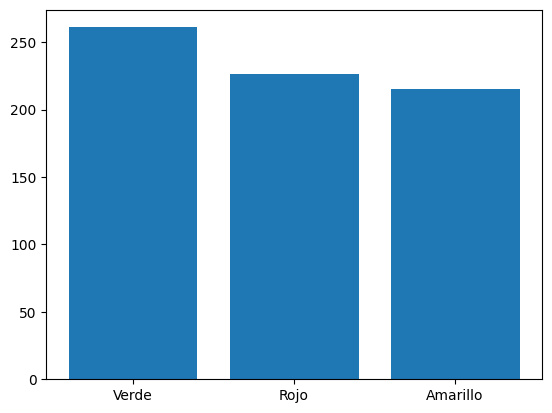

In [62]:
plt.bar((data_clean['color_semaforo_dominante'].value_counts()).index, (data_clean['color_semaforo_dominante'].value_counts()).values)

In [63]:
data_clean = pd.concat([data_clean, pd.get_dummies(data_clean['color_semaforo_dominante'], prefix= "color_semaforo_dominante", 
                                                   drop_first= True)], axis=1)

data_clean = data_clean.drop(columns= 'color_semaforo_dominante') # amarillo es la base

#### Codificación de `tipo_dia`

`tipo_dia` es una variable binaria con 2 categorías (Laborable, Fin de 
semana). Se aplica Label Encoding, que asigna 0 y 1 a las dos categorías. 
Con solo dos valores One-Hot Encoding generaría columnas redundantes, por 
lo que Label Encoding es la opción más eficiente.

In [64]:
data_clean['tipo_dia'].value_counts()

tipo_dia
Laborable        506
Fin de semana    196
Name: count, dtype: int64

In [65]:
# también puedes usar pd.get_dummies para tipo_dia con drop_first=True y el resultado sería idéntico-> para ver algo nuevo:
# subir a parte de librerias -> from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data_clean['tipo_dia']= le.fit_transform(data_clean['tipo_dia'])

In [66]:
print(le.classes_)
data_clean['tipo_dia'].value_counts()

['Fin de semana' 'Laborable']


tipo_dia
1    506
0    196
Name: count, dtype: int64

 Se aplica Label Encoding, que asigna 0 y 1 a las dos categorías 
siguiendo orden alfabético: Fin de semana → 0, Laborable → 1. Con solo 
dos valores One-Hot Encoding generaría exactamente 1 columna nueva tras 
aplicar `drop_first=True`, resultado idéntico al Label Encoding pero con 
más código, por lo que Label Encoding es la opción más eficiente. El 
resultado es consistente con la distribución original: 506 registros 
Laborable (1) y 196 registros Fin de semana (0).

In [67]:
data_clean.columns

Index(['dia_semana_num', 'tipo_dia', 'temperatura_c', 'humedad_relativa_pct',
       'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales',
       'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h',
       'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct',
       'numero_incidencias_app', 'indice_ruido_historico',
       'campana_publicitaria', 'congestion_alta', 'mes', 'distrito_Este',
       'distrito_Norte', 'distrito_Oeste', 'distrito_Sur',
       'distrito_Universidad', 'franja_horaria_Noche', 'franja_horaria_Tarde',
       'color_semaforo_dominante_Rojo', 'color_semaforo_dominante_Verde'],
      dtype='str')

In [68]:
# Guardamos una copia del dataset con las variables categóricas ya codificadas
# pero sin escalar, ya que el escalado solo es necesario para modelos sensibles
# a la escala como la regresión logística o SVM, y no para modelos de ensemble
# basados en árboles.
data_cod = data_clean.copy()

#### Resumen de variables tras la codificación

Tras aplicar las transformaciones de codificación, el dataset cuenta con 28 
columnas. Las variables originales que no requerían codificación se mantienen 
tal cual: `dia_semana_num`, `temperatura_c`, `humedad_relativa_pct`, 
`lluvia_mm`, `viento_kmh`, `aforo_vehiculos`, `accidentes_previos_24h`, 
`ocupacion_bus_pct`, `plazas_aparcamiento_libres`, `ocupacion_bici_pct`, 
`numero_incidencias_app`, `indice_ruido_historico` y `mes` son numéricas de 
origen. `evento_ciudad`, `obras_viales`, `festivo_local` y `campana_publicitaria` 
ya eran binarias (0/1). `tipo_dia` ha pasado de categórica binaria a numérica 
mediante Label Encoding (Fin de semana → 0, Laborable → 1).

Las variables categóricas con más de dos categorías han generado nuevas columnas 
binarias mediante One-Hot Encoding, eliminando en cada caso la categoría de 
referencia con `drop_first=True` para evitar multicolinealidad: `distrito` ha 
generado 5 columnas (`distrito_Este`, `distrito_Norte`, `distrito_Oeste`, 
`distrito_Sur`, `distrito_Universidad`), siendo Centro la categoría de 
referencia; `franja_horaria` ha generado 2 columnas (`franja_horaria_Noche`, 
`franja_horaria_Tarde`), siendo Mañana la referencia; y 
`color_semaforo_dominante` ha generado 2 columnas 
(`color_semaforo_dominante_Rojo`, `color_semaforo_dominante_Verde`), siendo 
Amarillo la referencia. La variable objetivo `congestion_alta` no se toca.

### Paso 6: Escalado de variables
#### Reflexión de la necesidad de escalado en los modelos que se van a probar

Antes de aplicar cualquier transformación de escalado es necesario reflexionar 
sobre qué modelos se van a entrenar y si realmente lo necesitan, ya que escalar 
innecesariamente no aporta nada y complica el pipeline.

Los modelos que se van a probar son los siguientes:

**Modelos de ensemble basados en árboles (Random Forest, XGBoost, CatBoost):** 
estos modelos toman decisiones mediante splits binarios (¿es `aforo_vehiculos` 
> 1500? sí/no) y no calculan distancias ni aplican regularización sobre los 
valores numéricos. El rango de las variables no afecta al resultado, por lo 
que **no necesitan escalado**. Se entrenarán sobre `data_cod`, el dataset con 
variables categóricas codificadas pero sin escalar.

**Regresión logística y SVM:** estos modelos calculan coeficientes sobre los 
valores de las variables y aplican regularización, por lo que son sensibles 
a la escala. Variables con rangos amplios como `aforo_vehiculos` (350-2785) 
dominarían sobre variables con rangos pequeños como `dia_semana_num` (0-6), 
distorsionando los coeficientes. **Sí necesitan escalado**.

Sin embargo, el escalado no puede aplicarse en este momento sobre todo el 
dataset. Hacerlo ahora implicaría ajustar el StandardScaler sobre todos los 
registros incluyendo los que luego formarán parte del test, lo que constituiría 
**data leakage**: el modelo estaría viendo información del test durante la 
preparación de los datos. El escalado debe aplicarse después de la partición 
train/test, ajustando el scaler únicamente sobre el conjunto de entrenamiento 
y aplicándolo después sobre el test. Por este motivo se posposne el escalado 
al momento de entrenar la regresión logística y el SVM.

Por este motivo se mantienen dos versiones del dataset: `data_cod` para los 
modelos de ensemble y el dataset escalado que se generará en el momento de 
entrenar la regresión logística y el SVM.

### Paso 7: Partición train/test

Antes de entrenar cualquier modelo es necesario dividir el dataset en dos 
subconjuntos: uno de entrenamiento (train) sobre el que el modelo aprende 
los patrones, y uno de test sobre el que se evalúa su capacidad de 
generalización a datos no vistos. Se aplica una partición 80/20, es decir, 
el 80% de los registros para entrenamiento y el 20% para test. Con 702 
registros esto supone 561 registros para train y 141 para test.

Se utiliza `stratify=y` para mantener en ambos subconjuntos la misma 
proporción de casos positivos y negativos que en el dataset original 
(73.75% / 26.25%), evitando que por azar el test quede desproporcionadamente 
cargado de una clase.

In [69]:
X = data_cod.drop(columns='congestion_alta')
print(f"Variables explicativas: {X.columns.tolist()}")

y = data_cod['congestion_alta']
y.head()

Variables explicativas: ['dia_semana_num', 'tipo_dia', 'temperatura_c', 'humedad_relativa_pct', 'lluvia_mm', 'viento_kmh', 'evento_ciudad', 'obras_viales', 'festivo_local', 'aforo_vehiculos', 'accidentes_previos_24h', 'ocupacion_bus_pct', 'plazas_aparcamiento_libres', 'ocupacion_bici_pct', 'numero_incidencias_app', 'indice_ruido_historico', 'campana_publicitaria', 'mes', 'distrito_Este', 'distrito_Norte', 'distrito_Oeste', 'distrito_Sur', 'distrito_Universidad', 'franja_horaria_Noche', 'franja_horaria_Tarde', 'color_semaforo_dominante_Rojo', 'color_semaforo_dominante_Verde']


0    1
1    1
2    0
3    1
4    1
Name: congestion_alta, dtype: int64

In [70]:
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [71]:
y_train.value_counts()

congestion_alta
1    415
0    146
Name: count, dtype: int64

In [72]:
y_test.value_counts()

congestion_alta
1    104
0     37
Name: count, dtype: int64

 El resultado confirma que la estratificación es 
correcta: train contiene 415 positivos (74%) y 146 negativos (26%), y test 
contiene 104 positivos (73.8%) y 37 negativos (26.2%). Se fija 
`random_state=42` para garantizar la reproducibilidad de la partición.

### Act 3: Preparación de los datos

| Paso | Decisión tomada | Justificación |
|---|---|---|
| Tratamiento de valores ausentes | Eliminación de registros nulos en `distrito` y `franja_horaria` (1.25% cada una). Imputación con mediana en `lluvia_mm` (1.39%, distribución asimétrica). Imputación con media en el resto de variables numéricas (`temperatura_c`, `humedad_relativa_pct`, `viento_kmh`, `accidentes_previos_24h`, `ocupacion_bus_pct`, `plazas_aparcamiento_libres`, `ocupacion_bici_pct`, `numero_incidencias_app`, `indice_ruido_historico`). | Las variables categóricas se eliminan porque imputar con la moda introduciría información falsa en variables muy discriminativas: el error es binario, o aciertas la categoría o te equivocas completamente. En variables numéricas el error es gradual y la media o mediana son aproximaciones razonables. Se usa mediana en `lluvia_mm` por su asimetría (skewness 2.25) y media en el resto al mostrar distribuciones simétricas (diferencia media-mediana inferior a 0.5 en todos los casos). |
| Codificación de categóricas | One-Hot Encoding con `drop_first=True` en `distrito` (5 columnas nuevas, referencia: Centro), `franja_horaria` (2 columnas nuevas, referencia: Mañana) y `color_semaforo_dominante` (2 columnas nuevas, referencia: Amarillo). Label Encoding en `tipo_dia` (Fin de semana → 0, Laborable → 1). Para CatBoost se mantiene una versión del dataset con las categóricas en su formato original, ya que este algoritmo las maneja de forma nativa. | Las variables nominales sin orden natural se codifican con One-Hot Encoding para evitar que el modelo interprete los códigos numéricos como magnitudes ordenadas. `tipo_dia` se codifica con Label Encoding al ser binaria. CatBoost utiliza Ordered Target Statistics internamente, por lo que codificar las categóricas antes de entrenar eliminaría esta ventaja. |
| Escalado | Aplicado de forma diferida para los modelos que lo requieren (Regresión Logística y SVM). No aplicado para modelos de ensemble basados en árboles (Random Forest, XGBoost, CatBoost). | Los modelos de ensemble toman decisiones mediante splits binarios y no son sensibles a la escala. La Regresión Logística y el SVM calculan coeficientes y distancias, por lo que sí requieren escalado. El escalado no puede aplicarse ahora sobre todo el dataset porque implicaría ajustar el StandardScaler incluyendo los registros de test, lo que constituiría data leakage. Se aplica después de la partición train/test, ajustando el scaler únicamente sobre train y transformando test. |
| Partición train/test | Partición 80/20 con `stratify=y` y `random_state=42`. Train: 561 registros (415 positivos, 146 negativos). Test: 141 registros (104 positivos, 37 negativos). | La estratificación garantiza que ambos subconjuntos mantienen la misma proporción de clases que el dataset original (73.75% / 26.25%), evitando que por azar el test quede desproporcionadamente cargado de una clase. `random_state=42` garantiza la reproducibilidad. |
| Otras transformaciones realizadas | Eliminación de variables por razones objetivas: `id_registro`, `id_sensor`, `fecha`, `año` y `dia` en el paso 1. Eliminación de `indice_congestion` por data leakage en el paso 2. Eliminación de `porcentaje_hombres_zona` por varianza casi nula y ausencia de justificación causal en el paso 3. Creación de la variable derivada `mes` a partir de `fecha`. Selección de las 10 variables más discriminativas mediante SelectKBest con f_classif para los modelos lineales. | Cada eliminación responde a un criterio técnico distinto: identificadores sin información predictiva, riesgo de data leakage y variables prácticamente constantes. La variable `mes` captura estacionalidad mensual. La selección de variables reduce el ruido en los modelos lineales, que son más sensibles a variables irrelevantes que los modelos de ensemble. |

## Entrenamiento de modelos

Se entrenan cinco modelos de distinta naturaleza para abordar el problema 
de clasificación binaria de congestión urbana. La estrategia es partir de 
un modelo base sencillo y explorar progresivamente algoritmos más complejos 
y de distinta familia, con el objetivo de identificar cuál generaliza mejor 
con este dataset.

Los tres primeros modelos pertenecen a la familia de **ensemble basados en 
árboles** (Random Forest, XGBoost y CatBoost). Son robustos ante variables 
con distintas escalas sin necesidad de escalado previo, manejan bien tanto 
variables numéricas como categóricas codificadas, ofrecen métricas de 
importancia de variables que facilitan la interpretación, y son especialmente 
adecuados para problemas de clasificación binaria con desbalance de clases. 
CatBoost destaca además por su manejo nativo de variables categóricas mediante 
Ordered Target Statistics, lo que permite entrenarle sin codificación previa.

Los dos últimos modelos son **modelos lineales** (Regresión Logística y SVM). 
A diferencia de los ensemble, estos modelos son sensibles a la escala de las 
variables y requieren escalado previo, así como una selección de variables 
para reducir el ruido introducido por variables poco discriminativas. Se 
incluyen para comprobar si la complejidad de los modelos de ensemble es 
realmente necesaria con este dataset o si un modelo más simple generaliza 
igual de bien.

### Random Forest

#### Entrenamiento del modelo Random Forest base

Como primer modelo se entrena un **Random Forest** con parámetros por 
defecto, a excepción de `class_weight='balanced'` para compensar el 
desbalance entre clases (74% congestión alta, 26% no congestión). El 
objetivo de este modelo base no es obtener el mejor resultado posible sino 
establecer un punto de referencia razonable que permita evaluar si los datos 
disponibles tienen capacidad predictiva suficiente para el problema planteado, 
antes de invertir esfuerzo en optimización de hiperparámetros o selección 
de variables.

In [73]:
# from sklearn.ensemble import RandomForestClassifier
rf_modelo1 = RandomForestClassifier(random_state=42,class_weight='balanced')

rf_modelo1.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
# evaluacion en train
predicciones_modelo1_train = rf_modelo1.predict(X_train)

print(classification_report(y_train, predicciones_modelo1_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      1.00      1.00       415

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561



#### Evaluación del modelo Random Forest base

El modelo base obtiene un accuracy de 1.0 sobre el conjunto de entrenamiento, 
con precisión, recall y F1 perfectos en ambas clases. Esto indica que el 
modelo ha memorizado completamente los datos de entrenamiento, lo que es 
un caso claro de sobreajuste. Este comportamiento es esperable en Random 
Forest con `max_depth=None`: los árboles crecen sin límite de profundidad 
hasta clasificar correctamente cada registro de train. Aunque los mecanismos 
de bagging y selección aleatoria de variables reducen el sobreajuste respecto 
a un árbol individual, no lo eliminan completamente con parámetros por defecto.

0.8226950354609929
              precision    recall  f1-score   support

           0       0.71      0.54      0.62        37
           1       0.85      0.92      0.88       104

    accuracy                           0.82       141
   macro avg       0.78      0.73      0.75       141
weighted avg       0.81      0.82      0.81       141



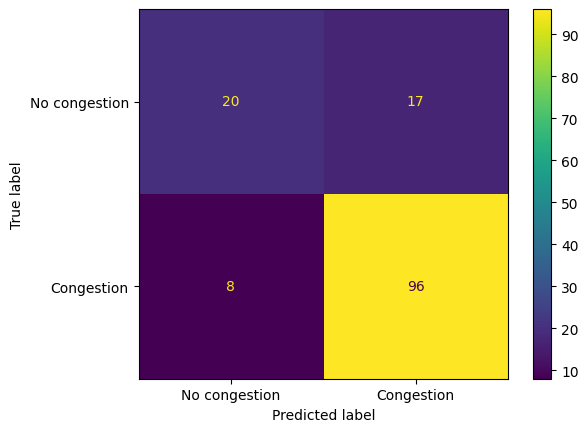

In [75]:
predicciones_modelo1_test = rf_modelo1.predict(X_test)

# from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

print(accuracy_score(y_test,predicciones_modelo1_test))
print(classification_report(y_test, predicciones_modelo1_test))

ConfusionMatrixDisplay(confusion_matrix(y_test, predicciones_modelo1_test),display_labels=['No congestion', 'Congestion']).plot()

En test el modelo obtiene un accuracy de 0.82. La matriz de confusión muestra 
96 verdaderos positivos, 20 verdaderos negativos, 8 falsos negativos y 17 
falsos positivos.

El modelo detecta bien la clase 1 (congestión alta), con un recall de 0.92 
que indica que identifica 96 de los 104 episodios reales de congestión. 
El punto débil es la clase 0 (no congestión), con un recall de 0.54 que 
significa que solo detecta 20 de los 37 casos reales de no congestión, 
dejando sin detectar 17 episodios a través de falsos positivos.

#### Optimización de hiperparámetros con Optuna

Antes de entrenar el modelo mejorado se realiza una búsqueda de 
hiperparámetros con Optuna. Optuna utiliza el algoritmo TPE (Tree-structured 
Parzen Estimator) para explorar el espacio de hiperparámetros de forma 
inteligente: en lugar de probar combinaciones aleatorias como GridSearch, 
aprende de los trials anteriores para dirigir la búsqueda hacia las zonas 
más prometedoras.

Se ejecutan 50 trials, cada uno entrenando un Random Forest con una 
combinación distinta de hiperparámetros y evaluándolo mediante validación 
cruzada de 5 folds sobre el conjunto de entrenamiento. La métrica de 
optimización es el **F1-macro**, que promedia el F1 de ambas clases por 
igual. Esta elección es importante: usar F1 de la clase positiva únicamente 
llevaría a Optuna a ignorar el rendimiento sobre la clase 0 (no congestión), 
optimizando solo para detectar congestión alta y penalizando el equilibrio 
entre clases. F1-macro obliga al modelo a rendir bien en ambas clases 
simultáneamente.

Los hiperparámetros explorados son `n_estimators` (número de árboles), 
`max_depth` (profundidad máxima), `min_samples_split` (mínimo de muestras 
para hacer un split), `min_samples_leaf` (mínimo de muestras en una hoja) 
y `max_features` (número de variables consideradas en cada split).

In [ ]:
#import optuna
#from sklearn.model_selection import cross_val_score
def objective(trial): # para cada trial TPE elige hiperparametros -> cv -> resultado como media de los folds 
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42
    )
    
    cv_scores = cross_val_score(model, X_train,y_train, cv=5, scoring='f1_macro')
    return cv_scores.mean() # media de los folds

In [ ]:
study = optuna.create_study(direction='maximize') # información del estudio
study.optimize(objective, n_trials=50) # ejecuta 50 veces la funcion objective, optimize es el bucle que orquesta todo para maximizar el accuracy

In [ ]:
study.best_params, study.best_value 

#### Entrenamiento del modelo optimizado con Optuna

A partir del modelo base se entrena un segundo Random Forest optimizando 
sus hiperparámetros mediante Optuna. Tras 50 trials el estudio identifica 
la combinación que maximiza el F1-macro.

In [ ]:
X_train.head()

El modelo se entrena con las mismas variables y transformaciones aplicadas 
en el modelo base: 27 variables predictoras tras la eliminación de variables 
irrelevantes, tratamiento de nulos, codificación de categóricas y partición 
train/test estratificada. La única diferencia respecto al modelo 1 es la 
optimización de hiperparámetros.

In [ ]:
rf_optuna = RandomForestClassifier(
    n_estimators=217,
    max_depth=13,
    min_samples_split=6,
    min_samples_leaf=4,
    max_features='log2',
    class_weight='balanced',
    random_state=42
)

rf_optuna.fit(X_train, y_train)

In [ ]:
prediccion_train_modelo2 = rf_optuna.predict(X_train)

confusion_modelo2 = confusion_matrix(y_train, prediccion_train_modelo2)

ConfusionMatrixDisplay(confusion_modelo2, display_labels=['No congestion', 'Congestion']).plot()

print(classification_report(y_train, prediccion_train_modelo2))

El modelo optimizado obtiene un accuracy de 0.93 sobre el conjunto de 
entrenamiento, frente al 1.0 del modelo base. Esta reducción del sobreajuste 
es una consecuencia directa de la optimización de hiperparámetros: limitar 
la profundidad máxima a `max_depth=13` impide que los árboles crezcan 
indefinidamente hasta memorizar cada registro, y aumentar `min_samples_leaf=4` 
obliga a que cada hoja contenga al menos 4 registros, evitando divisiones 
demasiado específicas. El modelo aprende patrones más generalizables en lugar 
de memorizar el conjunto de entrenamiento.

#### Evaluación del modelo  optimizado con Optuna


In [ ]:
prediccion_test_modelo2 = rf_optuna.predict(X_test)

ConfusionMatrixDisplay(confusion_matrix(y_test, prediccion_test_modelo2), display_labels=['No congestion', 'Congestion']).plot()
print(classification_report(y_test, prediccion_test_modelo2))

En test el modelo optimizado obtiene un accuracy de 0.75, inferior al 0.82 
del modelo base. La matriz de confusión muestra 86 verdaderos positivos, 
20 verdaderos negativos, 18 falsos negativos y 17 falsos positivos.

A pesar de haber reducido el sobreajuste en train, el modelo optimizado 
generaliza peor al test que el modelo base. El recall de la clase 1 baja 
de 0.92 a 0.83, perdiendo 10 episodios reales de congestión adicionales. 
La clase 0 no mejora respecto al modelo base, manteniendo los mismos 17 
falsos positivos.

Este resultado confirma que la optimización de hiperparámetros mediante 
Optuna no ha aportado mejora real sobre este dataset. El modelo base con 
parámetros por defecto, a pesar de su sobreajuste en train, generaliza 
mejor al test. 

In [ ]:
predicciones_prob_modelo1 = rf_modelo1.predict_proba(X_test)
prob_clase1_modelo1 = predicciones_prob_modelo1[:, 1]
umbral = 0.7
predicciones_umbral = (prob_clase1_modelo1 >= umbral).astype(int)
print(classification_report(y_test, predicciones_umbral))

Se prueba a subir el umbral de decisión de 0.5 a 0.7 para reducir los 
falsos positivos del modelo base. La lógica es correcta: al exigir una 
probabilidad más alta para predecir congestión, el modelo solo clasifica 
como congestión alta cuando está muy seguro, lo que debería reducir las 
falsas alarmas.

Sin embargo el resultado no mejora. El recall de la clase 1 baja de 0.92 
a 0.77, perdiendo 15 episodios reales de congestión adicionales, sin que 
los falsos positivos se reduzcan de forma significativa. Esto ocurre porque 
las probabilidades del modelo se concentran en valores cercanos a 0 y 1, 
con pocos casos en la zona intermedia. Subir el umbral a 0.7 convierte en 
"no congestión" casos que el modelo predecía con probabilidad entre 0.5 y 
0.7, generando más falsos negativos sin compensar con una reducción real 
de los falsos positivos. El ajuste de umbral se descarta como estrategia 
de mejora.

#### Importancia de las variables del modelo

El gráfico SHAP summary plot muestra el impacto de cada variable sobre la 
predicción del modelo, ordenadas de mayor a menor importancia. Cada punto 
representa un registro del test: el color indica el valor de la variable 
(rojo = alto, azul = bajo) y la posición horizontal indica el impacto sobre 
la predicción (derecha = empuja hacia congestión alta, izquierda = empuja 
hacia no congestión).


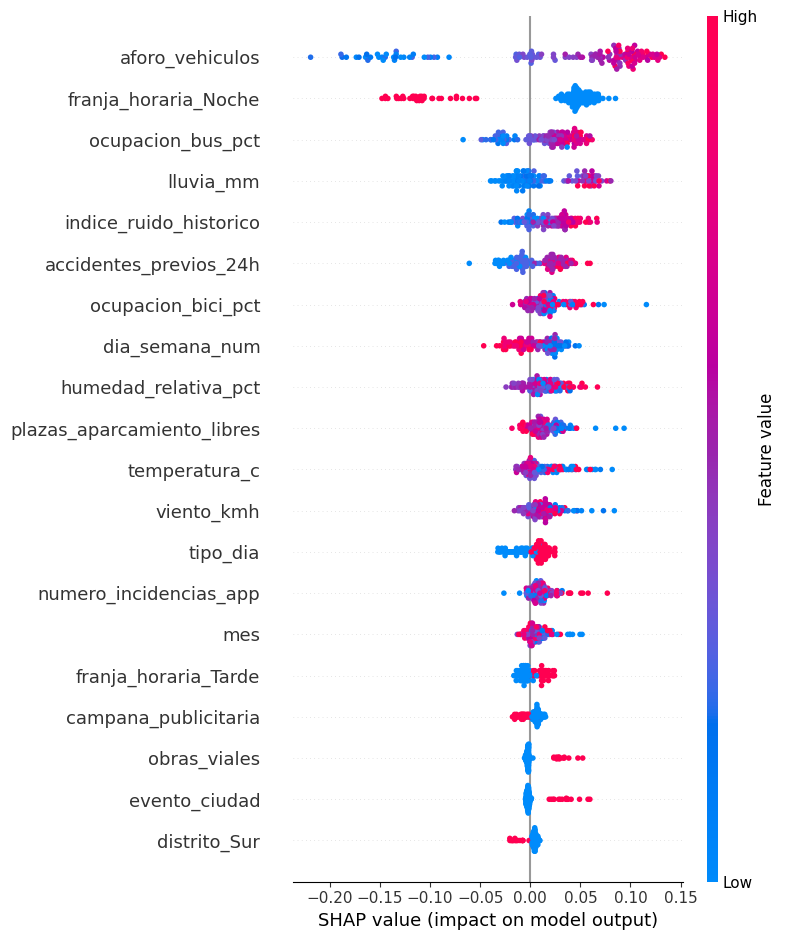

In [88]:
explainer = shap.TreeExplainer(rf_modelo1)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)


Las variables más relevantes son:

`aforo_vehiculos` es la variable más importante con diferencia. Valores altos 
(rojo) empujan fuertemente hacia congestión alta, lo que tiene sentido causal 
directo: más vehículos implica más probabilidad de congestión.

`franja_horaria_Noche` es la segunda variable más importante. Valores altos 
(es decir, que sea de noche) empujan hacia no congestión, lo que es coherente 
con la menor actividad urbana nocturna.

`ocupacion_bus_pct`, `lluvia_mm` e `indice_ruido_historico` tienen un impacto 
moderado pero consistente, con valores altos asociados a mayor congestión.

En la parte inferior del gráfico aparecen variables con impacto muy reducido 
como `distrito_Sur`, `evento_ciudad`, `obras_viales`, `campana_publicitaria` 
o `franja_horaria_Tarde`, cuyos valores SHAP se concentran cerca de cero. 
Estas variables apenas contribuyen a las predicciones del modelo y son 
candidatas a ser eliminadas en una selección de variables para el modelo 2.

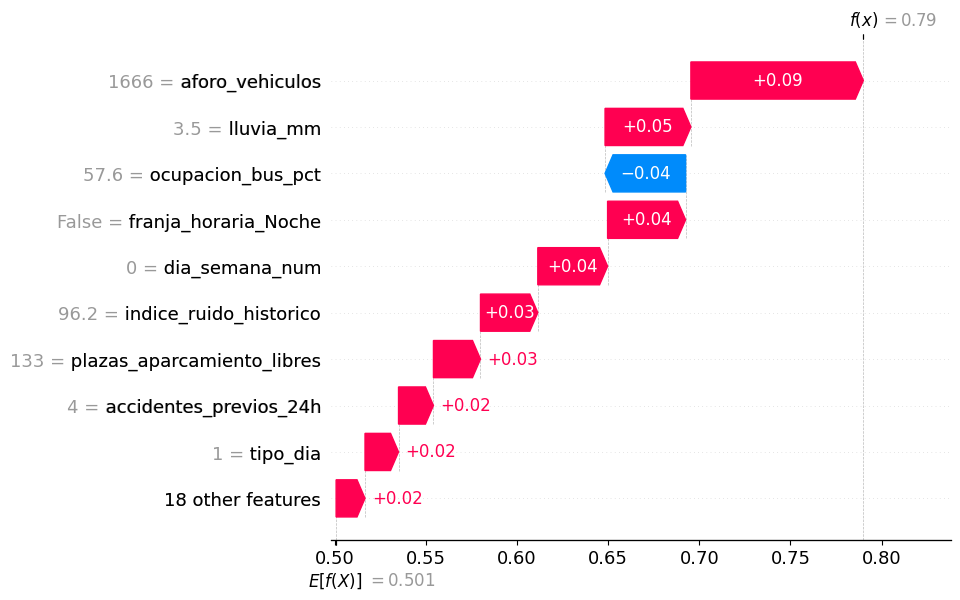

In [89]:
# Waterfall plot de un caso de congestión alta
idx = np.where(y_test == 1)[0][0]  # primer caso de congestión alta en test

shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[idx],
    feature_names=X_test.columns.tolist()
))

El waterfall plot muestra cómo el modelo llega a una predicción concreta 
para un registro de congestión alta. El punto de partida es el valor base 
`E[f(X)] = 0.501`, que representa la probabilidad media de congestión alta 
en el conjunto de test. Cada barra muestra cuánto empuja cada variable 
hacia arriba (rojo, aumenta la probabilidad) o hacia abajo (azul, reduce 
la probabilidad) hasta llegar a la predicción final de `f(x) = 0.79`.

En este registro concreto, `aforo_vehiculos` es la variable que más 
contribuye a la predicción con un valor de 1666 vehículos (+0.09), seguida 
de `lluvia_mm` con 3.5mm (+0.05) y `franja_horaria_Noche = False` (+0.04), 
que indica que no es de noche y por tanto empuja hacia congestión. 
`dia_semana_num = 0` (lunes) también contribuye positivamente (+0.04). 
La única variable que reduce la probabilidad de congestión es 
`ocupacion_bus_pct` con un valor de 57.6% (-0.04), lo que podría indicar 
que una ocupación moderada del autobús se asocia con menor congestión en 
este contexto. El resto de variables contribuyen de forma más modesta pero 
todas en la misma dirección positiva.

In [ ]:
shap.dependence_plot('aforo_vehiculos', shap_values[:, :, 1], X_test)

El dependence plot muestra la relación entre el valor de `aforo_vehiculos` 
y su impacto SHAP sobre la predicción, con el color indicando el valor de 
`mes` (variable con mayor interacción detectada automáticamente por SHAP).

La relación es clara y monotónica: a mayor aforo de vehículos, mayor es el 
impacto positivo sobre la probabilidad de congestión alta. Por debajo de 
aproximadamente 1200 vehículos el impacto es negativo (empuja hacia no 
congestión), mientras que a partir de 1500 vehículos el impacto se vuelve 
claramente positivo y crece de forma continua hasta los 2500 vehículos.

Respecto a la interacción con `mes`, no se aprecia un patrón claro: los 
puntos de distintos meses se mezclan sin una separación evidente, lo que 
sugiere que el mes no modifica significativamente la relación entre aforo 
y congestión. El aforo de vehículos actúa como predictor independiente del 
mes del año.

#### Selección de variables basada en SHAP

El análisis SHAP del modelo base revela que un subconjunto reducido de 
variables concentra prácticamente todo el poder predictivo del modelo. 
Variables como `aforo_vehiculos`, `franja_horaria_Noche`, `ocupacion_bus_pct`, 
`lluvia_mm` e `indice_ruido_historico` tienen impactos SHAP claramente 
positivos y consistentes, mientras que variables como 
`color_semaforo_dominante_Rojo`, `color_semaforo_dominante_Verde`, 
`distrito_Sur`, `evento_ciudad`, `obras_viales` y `campana_publicitaria` 
tienen valores SHAP concentrados en torno a cero, indicando que no 
contribuyen a las predicciones del modelo.

Mantener variables sin capacidad predictiva introduce ruido innecesario 
que puede perjudicar la generalización, especialmente con un dataset 
pequeño de 702 registros. Se entrena un segundo Random Forest utilizando 
únicamente las variables con impacto SHAP relevante, con el objetivo de 
reducir el ruido y obtener un modelo más robusto, interpretable y 
eficiente operativamente.

In [ ]:
variables_shap = ['aforo_vehiculos', 'franja_horaria_Noche', 'ocupacion_bus_pct',
                  'lluvia_mm', 'indice_ruido_historico', 'accidentes_previos_24h',
                  'ocupacion_bici_pct', 'dia_semana_num', 'humedad_relativa_pct',
                  'plazas_aparcamiento_libres']

X_train_shap = X_train[variables_shap]
X_test_shap = X_test[variables_shap]

rf_shap = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_shap.fit(X_train_shap, y_train)
print(classification_report(y_test, rf_shap.predict(X_test_shap)))

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_shap.predict(X_test_shap)), 
                       display_labels=['No congestion', 'Congestion']).plot()

El Random Forest entrenado únicamente con las 10 variables más importantes 
según SHAP no mejora al modelo base en ninguna métrica. La accuracy baja 
de 0.82 a 0.80, el recall de clase 1 baja de 0.92 a 0.89 y el F1 de clase 
0 baja de 0.62 a 0.59. El recall de clase 0 se mantiene igual en 0.54.

Este resultado indica que las variables descartadas, aunque con impacto 
SHAP individual bajo, contribuyen de forma conjunta a la capacidad predictiva 
del modelo. Random Forest aprovecha todas las variables disponibles en cada 
split mediante su mecanismo de selección aleatoria, por lo que eliminar 
variables con impacto bajo no reduce el ruido sino que reduce la información 
disponible. La selección de variables basada en SHAP es más útil para modelos 
lineales, donde las variables irrelevantes introducen ruido real en los 
coeficientes. Se descarta esta estrategia y se mantiene el modelo base como 
referencia.

### Act 4: Modelo 1 (base)

| Elemento | Respuesta |
|---|---|
| Algoritmo utilizado | Random Forest con parámetros por defecto. Se elige Random Forest como modelo base por ser un algoritmo de ensemble robusto que no requiere apenas configuración previa, maneja bien variables de distinta naturaleza y escala, y proporciona métricas de importancia de variables útiles para fases posteriores. Es un punto de partida razonable y sólido antes de explorar optimizaciones más costosas. Los resultados confirman que el modelo tiene sentido: obtiene un accuracy de 0.82 y un F1 de 0.88 en la clase de congestión alta, lo que indica que las variables disponibles contienen información suficiente para anticipar episodios de congestión. |
| Variables utilizadas | Las 27 variables predictoras resultantes tras la preparación del dataset: variables numéricas originales (`aforo_vehiculos`, `temperatura_c`, `humedad_relativa_pct`, `lluvia_mm`, `viento_kmh`, `accidentes_previos_24h`, `ocupacion_bus_pct`, `plazas_aparcamiento_libres`, `ocupacion_bici_pct`, `numero_incidencias_app`, `indice_ruido_historico`), variables binarias de origen (`evento_ciudad`, `obras_viales`, `festivo_local`, `campana_publicitaria`, `dia_semana_num`, `mes`, `tipo_dia`), y variables generadas por One-Hot Encoding (`distrito_Este`, `distrito_Norte`, `distrito_Oeste`, `distrito_Sur`, `distrito_Universidad`, `franja_horaria_Noche`, `franja_horaria_Tarde`, `color_semaforo_dominante_Rojo`, `color_semaforo_dominante_Verde`). Se incluyen todas las variables disponibles tras la preparación del dataset sin filtrado previo, dejando que el propio modelo determine su importancia mediante su mecanismo interno de selección aleatoria de variables en cada split (`max_features='sqrt'`). La variable objetivo `congestion_alta` no se incluye como predictor. |
| Transformaciones aplicadas | Las descritas en el Act 3: eliminación de variables irrelevantes y con data leakage, tratamiento de valores ausentes por eliminación o imputación, codificación de variables categóricas mediante One-Hot Encoding y Label Encoding, y partición train/test 80/20 estratificada. No se aplica escalado al ser un modelo basado en árboles. |
| Parámetros más relevantes | `class_weight='balanced'` para compensar el desbalance de clases (74% congestión alta, 26% no congestión), evitando que el modelo ignore la clase minoritaria al penalizar más los errores en la clase menos frecuente. `random_state=42` para garantizar la reproducibilidad. `n_estimators=100` árboles en el ensemble. `max_depth=None` sin límite de profundidad, lo que permite a los árboles crecer hasta memorizar el conjunto de entrenamiento (accuracy 1.0 en train), aunque los mecanismos de bagging y selección aleatoria de variables reducen el sobreajuste en test. `max_features='sqrt'` considera la raíz cuadrada del número de variables en cada split, decorrelando los árboles entre sí. `min_samples_split=2` y `min_samples_leaf=1` con valores mínimos que permiten divisiones muy específicas. `criterion='gini'` como criterio de impureza. `bootstrap=True` con muestreo bootstrap para el bagging. |
| Optimización de hiperparámetros | Se aplica Optuna con 50 trials y F1-macro como métrica de optimización para buscar una combinación de hiperparámetros que mejore la generalización. Los mejores parámetros encontrados son `n_estimators=217`, `max_depth=13`, `min_samples_split=6`, `min_samples_leaf=4` y `max_features='log2'`, con un F1-macro de 0.698 en validación cruzada. Sin embargo el modelo optimizado obtiene 0.75 de accuracy en test, inferior al 0.82 del modelo base, confirmando que el modelo base con parámetros por defecto generaliza mejor con este dataset. |
| Ajuste del umbral | Se prueba a subir el umbral de decisión de 0.5 a 0.7 para reducir los 17 falsos positivos del modelo base. El resultado no mejora: el recall de clase 1 baja de 0.92 a 0.77 sin reducir significativamente los falsos positivos, porque las probabilidades del modelo se concentran en valores alejados de 0.5 y subir el umbral genera más falsos negativos sin compensación. Se descarta como estrategia de mejora. |
| Selección de variables | Se entrena un segundo Random Forest con las 10 variables más importantes según el análisis SHAP. El resultado es inferior al modelo base en todas las métricas (accuracy 0.80 vs 0.82), confirmando que en modelos de ensemble la selección de variables basada en importancia individual no mejora el rendimiento: Random Forest aprovecha todas las variables disponibles en cada split y las variables con impacto SHAP bajo contribuyen de forma conjunta a la capacidad predictiva. |
| Explicabilidad del modelo | Se aplica SHAP (SHapley Additive exPlanations) para interpretar las predicciones del modelo. El summary plot identifica `aforo_vehiculos` como la variable más importante, con valores altos empujando fuertemente hacia congestión alta. `franja_horaria_Noche` es la segunda variable más relevante, con valores altos (es de noche) empujando hacia no congestión. El waterfall plot de un caso concreto muestra cómo el modelo llega a una probabilidad de 0.79 partiendo de una base de 0.501, con `aforo_vehiculos` (+0.09) y `lluvia_mm` (+0.05) como principales contribuyentes positivos. El dependence plot de `aforo_vehiculos` confirma una relación monotónica clara: por debajo de 1200 vehículos el impacto es negativo y por encima de 1500 es claramente positivo y creciente. |

In [ ]:
print(rf_modelo1.get_params())

### XGBoost

El modelo base de Random Forest ha alcanzado su techo con este dataset. 
La optimización de hiperparámetros mediante Optuna y el ajuste del umbral 
de decisión no han producido mejoras significativas, lo que indica que el 
problema no está en la configuración del algoritmo sino en el mecanismo de 
aprendizaje en sí. Random Forest construye cada árbol de forma independiente 
sobre una muestra bootstrap del dataset (bagging) y promedia las predicciones, 
lo que lo hace robusto pero limita su capacidad de corregir errores sistemáticos.

Como modelo mejorado se entrena un **XGBoost** (Extreme Gradient Boosting). 
A diferencia de Random Forest, XGBoost construye los árboles de forma 
secuencial: cada árbol nuevo se entrena para corregir los errores del árbol 
anterior, de modo que el modelo se va ajustando iterativamente a los casos 
más difíciles de clasificar. Este mecanismo de boosting es especialmente 
útil cuando el modelo base tiene errores sistemáticos concentrados en una 
clase, como ocurre aquí con la clase 0 (no congestión), donde el Random 
Forest fallaba consistentemente con 17 falsos positivos.

Adicionalmente, XGBoost incorpora regularización L1 y L2 sobre los pesos 
de los árboles, lo que reduce el sobreajuste y mejora la generalización 
a datos no vistos. Se optimizarán sus hiperparámetros mediante Optuna 
con F1-macro como métrica de optimización, para garantizar un rendimiento 
equilibrado entre ambas clases.

#### Entrenamiento y evaluación de XGBoost básico

In [ ]:
#from xgboost import XGBClassifier

xgboost_modelo3 = XGBClassifier(
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)
xgboost_modelo3.fit(X_train, y_train)
print(classification_report(y_test, xgboost_modelo3.predict(X_test)))

El modelo XGBoost con parámetros por defecto obtiene un accuracy de 0.76, 
inferior al 0.82 del Random Forest base. La clase 1 (congestión alta) 
obtiene un F1 de 0.83 con recall de 0.83, detectando 86 de los 104 episodios 
reales de congestión. La clase 0 (no congestión) obtiene un F1 de 0.55 con 
recall de 0.57, resultado similar al Random Forest base en esta clase.

Sin optimización, XGBoost no supera al Random Forest base en ninguna métrica 
relevante. Se procede a optimizar sus hiperparámetros mediante Optuna.

#### Optimización de hiperparámetros con Optuna


In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42,
        eval_metric='logloss'
    )
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    return cv_scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)
print(study_xgb.best_params)
print(study_xgb.best_value)

#### Entrenamiento evaluación de modelo optimizado con Optuna

In [ ]:
# con los hiperparametros
xgb_optuna = XGBClassifier(
    n_estimators=174,
    max_depth=7,
    learning_rate=0.01961163421768065,
    subsample=0.6264166722035517,
    colsample_bytree=0.6062964014027945,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)

xgb_optuna.fit(X_train, y_train)
print(classification_report(y_test, xgb_optuna.predict(X_test)))

El modelo XGBoost optimizado con Optuna obtiene resultados similares al 
Random Forest base: accuracy de 0.76, F1 de 0.83 en clase 1 y F1 de 0.56 
en clase 0. Ni el cambio de algoritmo ni la optimización de hiperparámetros 
han conseguido superar el modelo base de Random Forest, que con parámetros 
por defecto alcanzaba un accuracy de 0.82 y un F1 de 0.88 en clase 1.

Este patrón consistente a través de distintos algoritmos y configuraciones 
apunta a que el techo no está en el modelo sino en los datos: con 702 
registros y un desbalance 74/26, la clase 0 (no congestión) tiene solo 189 
casos reales, lo que es insuficiente para que cualquier algoritmo aprenda 
sus patrones con fiabilidad.

#### SMOTE Synthetic Minority Oversampling Technique

Para abordar este problema directamente se aplica **SMOTE** (Synthetic 
Minority Oversampling Technique), una técnica que genera observaciones 
sintéticas de la clase minoritaria interpolando entre los casos existentes. 
A diferencia de `class_weight='balanced'`, que solo ajusta los pesos durante 
el entrenamiento, SMOTE aumenta físicamente el número de ejemplos de la 
clase 0 en el conjunto de entrenamiento, proporcionando al modelo más 
información real sobre los patrones de no congestión. Se combina con XGBoost 
al ser el algoritmo que mejor maneja datos sintéticos de entre los probados.

In [ ]:
# from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribución antes de SMOTE:")
print(y_train.value_counts())
print("\nDistribución después de SMOTE:")
print(pd.Series(y_train_smote).value_counts())

#### Evolución de los modelos XGBoost con SMOTE

In [ ]:
xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)
print(classification_report(y_test, xgb_smote.predict(X_test)))

In [ ]:
xgb_smote2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=2,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200
)

xgb_smote2.fit(X_train_smote, y_train_smote)
print(classification_report(y_test, xgb_smote2.predict(X_test)))

In [ ]:
xgb_smote3 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=1.5,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200
)

xgb_smote3.fit(X_train_smote, y_train_smote)
print(classification_report(y_test, xgb_smote3.predict(X_test)))

Se han entrenado tres versiones del modelo XGBoost con el objetivo de 
mejorar progresivamente el rendimiento sobre la clase minoritaria:

**XGBoost base con SMOTE** — El primer modelo combina XGBoost con parámetros 
por defecto sobre el dataset equilibrado por SMOTE (415 casos de cada clase 
en train). Obtiene un accuracy de 0.77 y un F1-macro de 0.70, ligera mejora 
respecto al XGBoost sin SMOTE (0.76) pero sin superar el Random Forest base.

**XGBoost con SMOTE y scale_pos_weight=2** — Se añade un peso adicional 
a la clase 0 durante el entrenamiento (`scale_pos_weight=2`) junto con 
`max_depth=5`, `learning_rate=0.1` y `n_estimators=200`. Obtiene el mejor 
resultado hasta el momento en esta parte con accuracy de 0.79, precisión de clase 0 de 
0.64 y recall de clase 1 de 0.90. La combinación de SMOTE y pesos adicionales 
refuerza la atención del modelo sobre la clase minoritaria desde dos frentes: 
más ejemplos sintéticos y mayor penalización por error.

**XGBoost con SMOTE y scale_pos_weight=1.5** — Se reduce el peso a 1.5 
para buscar un equilibrio más fino entre las dos clases. El resultado 
empeora respecto al anterior (accuracy 0.77), confirmando que `scale_pos_weight=2` 
es la configuración más adecuada de las probadas hasta ahora. Se procede 
a optimizar los hiperparámetros con Optuna para intentar mejorar este resultado.

In [ ]:
# OPTUNA SOBRE SMOTE
def objective_smote(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 3.0)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='f1_macro')
    return cv_scores.mean()

study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=50)
print(study_smote.best_params)
print(study_smote.best_value)

In [ ]:
xgb_smote_optuna = XGBClassifier(
    n_estimators=364,
    max_depth=7,
    learning_rate=0.039356888995784725,
    subsample=0.5575756277777317,
    colsample_bytree=0.9021258381890003,
    scale_pos_weight=1.1761625951797081,
    random_state=42,
    eval_metric='logloss'
)

xgb_smote_optuna.fit(X_train_smote, y_train_smote)
print(classification_report(y_test, xgb_smote_optuna.predict(X_test)))

El modelo XGBoost con SMOTE optimizado mediante Optuna obtiene un accuracy 
de 0.78 y un F1-macro de 0.71, con una precisión de clase 0 de 0.58 y un 
recall de clase 1 de 0.86. A pesar de que Optuna encontró un F1-macro de 
0.858 en validación cruzada, el rendimiento en test es notablemente inferior, 
lo que indica que el modelo ha sobreajustado a los folds de validación.

La combinación de SMOTE y optimización de hiperparámetros no ha conseguido 
superar al Random Forest base (accuracy 0.82, F1-macro 0.75). El problema 
de fondo persiste: con 189 casos reales de clase 0, ni la generación de 
datos sintéticos ni la optimización de hiperparámetros son suficientes para 
que el modelo aprenda los patrones de no congestión con fiabilidad.

En este punto se ha explorado exhaustivamente la familia de modelos de 
ensemble basados en boosting. El siguiente paso es probar **CatBoost**, 
que a diferencia de XGBoost trabaja con las variables categóricas en su 
formato original mediante Ordered Target Statistics, lo que puede aportar 
una perspectiva distinta al problema al no depender de la codificación 
previa realizada en el Act 3.

### CatBoost

CatBoost (Categorical Boosting) es un algoritmo de gradient boosting 
desarrollado por Yandex que destaca por su manejo nativo de variables 
categóricas. A diferencia de XGBoost o Random Forest, CatBoost no requiere 
codificación previa de las variables categóricas: internamente utiliza 
Ordered Target Statistics para convertir las categorías en valores numéricos 
de forma que evita data leakage durante el entrenamiento.

Esta característica lo hace especialmente relevante para este dataset, donde 
variables como `distrito`, `franja_horaria` y `color_semaforo_dominante` son 
categóricas con información potencialmente valiosa. Al trabajar con las 
categorías originales en lugar de columnas binarias generadas por One-Hot 
Encoding, CatBoost puede capturar relaciones más ricas entre las categorías 
y la variable objetivo. Por este motivo se entrena sobre `data_min`, el 
dataset que se conservó antes de aplicar la codificación de variables 
categóricas durante la preparación de los datos, aprovechando al máximo 
esta ventaja del algoritmo.

#### Visualización de los datos que se emplean

In [ ]:
data_min.head()
data_min.isna().sum() # sin nulos y sin codificar

#### Preparación de los datos para el modelo 

In [91]:
X_cat = data_min.drop(columns='congestion_alta')
y_cat = data_min['congestion_alta']

# Índices de columnas categóricas para CatBoost
cat_features = [X_cat.columns.get_loc(col) for col in ['distrito', 'tipo_dia', 'franja_horaria', 'color_semaforo_dominante']]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

In [ ]:
cat_features # guay

In [ ]:
X_train_cat.head() # son los indices

#### Entrenamiento y evaluación de distintas configuraciones de modelos

In [ ]:
cat_modelo = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0
)

cat_modelo.fit(X_train_cat, y_train_cat,cat_features=cat_features)
print(classification_report(y_test_cat, cat_modelo.predict(X_test_cat)))

CatBoost, aprovechando su manejo nativo de variables categóricas mediante 
Ordered Target Statistics, obtiene resultados prácticamente idénticos a 
XGBoost: accuracy de 0.76, F1 de 0.83 en clase 1 y F1 de 0.57 en clase 0. 
A pesar de trabajar con las variables categóricas en su formato original sin 
necesidad de codificación previa, el rendimiento no mejora respecto al 
Random Forest base.


In [92]:
cat_modelo2 = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0,
    depth=6,
    learning_rate=0.05,
    iterations=500,
    l2_leaf_reg=5
)

cat_modelo2.fit(X_train_cat, y_train_cat, cat_features=cat_features)
print(classification_report(y_test_cat, cat_modelo2.predict(X_test_cat)))

              precision    recall  f1-score   support

           0       0.66      0.62      0.64        37
           1       0.87      0.88      0.88       104

    accuracy                           0.82       141
   macro avg       0.76      0.75      0.76       141
weighted avg       0.81      0.82      0.81       141



In [ ]:
cat_modelo3 = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0,
    depth=5,
    learning_rate=0.03,
    iterations=700,
    l2_leaf_reg=10,
    border_count=64
)

cat_modelo3.fit(X_train_cat, y_train_cat, cat_features=cat_features)
print(classification_report(y_test_cat, cat_modelo3.predict(X_test_cat)))

In [ ]:
cat_modelo4 = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0,
    depth=6,
    learning_rate=0.08,
    iterations=400,
    l2_leaf_reg=3
)

cat_modelo4.fit(X_train_cat, y_train_cat, cat_features=cat_features)
print(classification_report(y_test_cat, cat_modelo4.predict(X_test_cat)))

Tras probar varias configuraciones, el mejor modelo CatBoost obtiene un 
accuracy de 0.82, igualando al Random Forest base, con una mejora en el 
F1-macro (0.76 vs 0.75) y en el F1 de clase 0 (0.64 vs 0.62). La 
configuración óptima encontrada es `depth=6`, `learning_rate=0.05`, 
`iterations=500` y `l2_leaf_reg=5`, que equilibra la capacidad de 
aprendizaje con la regularización necesaria para evitar sobreajuste.

El manejo nativo de variables categóricas mediante Ordered Target Statistics 
ha aportado una ligera mejora respecto a los modelos anteriores que trabajaban 
con variables codificadas. CatBoost es el primer modelo que iguala al Random 
Forest base y mejora ligeramente el F1-macro, convirtiéndose en el mejor 
modelo de ensemble hasta el momento.

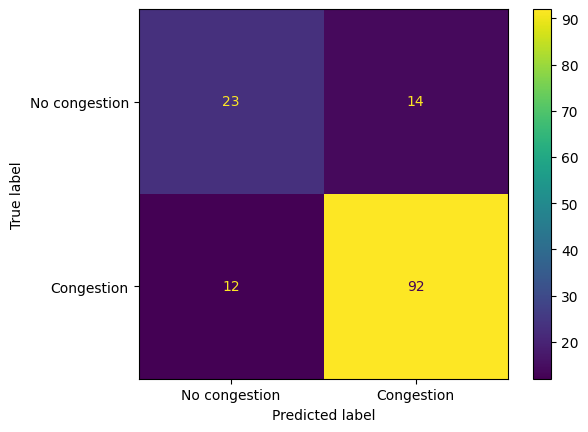

In [95]:
ConfusionMatrixDisplay(confusion_matrix(y_test_cat, cat_modelo2.predict(X_test_cat)), 
                       display_labels=['No congestion', 'Congestion']).plot()

#### Explicabilidad del mejor modelo CatBoost

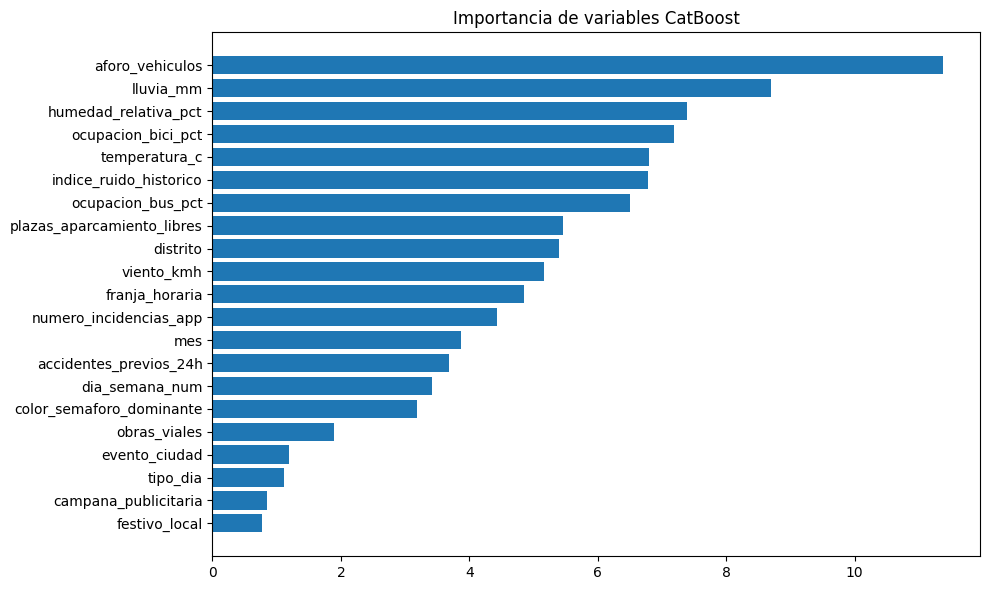

In [93]:
feature_importance = pd.DataFrame({
    'variable': X_train_cat.columns,
    'importancia': cat_modelo2.get_feature_importance()
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['variable'], feature_importance['importancia'])
plt.title('Importancia de variables CatBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La importancia interna de CatBoost mide cuánto contribuye cada variable 
a la reducción de la función de pérdida a lo largo de todos los árboles. 
`aforo_vehiculos` es con diferencia la variable más importante (11.2), 
confirmando el patrón observado en el Random Forest. Le siguen `lluvia_mm` 
(8.5) y `humedad_relativa_pct` (7.3), que en el Random Forest tenían una 
importancia mucho menor. Esto sugiere que CatBoost, al trabajar con las 
variables categóricas en su formato original, redistribuye la importancia 
entre las variables numéricas de forma distinta.

`distrito` y `franja_horaria` aparecen en posiciones intermedias (8ª y 11ª) 
como variables únicas, mientras que en el Random Forest estaban fragmentadas 
en múltiples columnas binarias. Esto es una ventaja directa del manejo nativo 
de categóricas: CatBoost captura la información de `franja_horaria` en una 
sola variable en lugar de distribuirla entre `franja_horaria_Noche` y 
`franja_horaria_Tarde`, lo que hace la interpretación más natural.

Las variables con menor importancia son `festivo_local`, `campana_publicitaria`, 
`tipo_dia` y `evento_ciudad`, todas por debajo de 1.5, confirmando el patrón 
observado en el análisis SHAP del Random Forest.

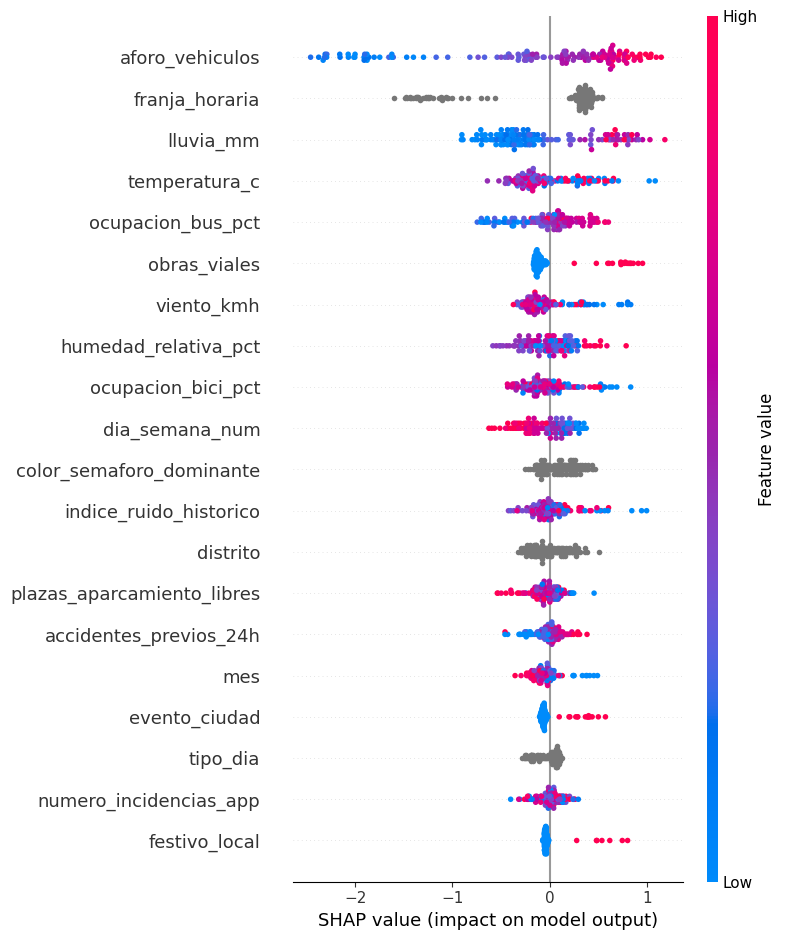

In [94]:
explainer_cat = shap.TreeExplainer(cat_modelo2)
shap_values_cat = explainer_cat.shap_values(X_test_cat)
shap.summary_plot(shap_values_cat, X_test_cat)


El SHAP summary plot de CatBoost muestra diferencias relevantes respecto 
al Random Forest. `aforo_vehiculos` mantiene su posición como variable más 
importante, con valores altos (rojo) empujando fuertemente hacia congestión 
alta y valores bajos (azul) hacia no congestión, con una separación muy 
clara entre ambos grupos.

`franja_horaria` sube al segundo puesto en el ranking SHAP, a pesar de 
aparecer en undécima posición en la importancia interna. Esto se debe a 
que la importancia interna mide la contribución media a lo largo de todos 
los árboles, mientras que SHAP mide el impacto real sobre cada predicción 
individual. `franja_horaria` aparece en gris porque es una variable 
categórica y SHAP no puede asignarle un gradiente de color continuo, al 
igual que `distrito` y `color_semaforo_dominante`.

`lluvia_mm` y `temperatura_c` tienen un impacto SHAP más relevante en 
CatBoost que en Random Forest, con valores altos asociados a mayor congestión. 
`obras_viales` sube posiciones respecto al Random Forest, lo que sugiere 
que CatBoost aprovecha mejor esta variable binaria en combinación con las 
categóricas originales.

En la parte inferior del ranking aparecen `festivo_local`, 
`numero_incidencias_app` y `tipo_dia` con valores SHAP concentrados cerca 
de cero, confirmando que su contribución a las predicciones individuales 
es mínima independientemente del algoritmo utilizado.

#### Modelo CatBoost simplificado con las variables que mas influyen

In [ ]:
variables_eliminar = ['festivo_local', 'campana_publicitaria', 'tipo_dia', 'evento_ciudad']

X_train_cat2 = X_train_cat.drop(columns=variables_eliminar)
X_test_cat2 = X_test_cat.drop(columns=variables_eliminar)

cat_features2 = [X_train_cat2.columns.get_loc(col) for col in ['distrito', 'franja_horaria', 'color_semaforo_dominante']]

cat_modelo5 = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0,
    depth=6,
    learning_rate=0.05,
    iterations=500,
    l2_leaf_reg=5
)

cat_modelo5.fit(X_train_cat2, y_train_cat, cat_features=cat_features2)
print(classification_report(y_test_cat, cat_modelo5.predict(X_test_cat2)))

Se prueba a eliminar las variables con importancia casi nula (`festivo_local`, 
`campana_publicitaria`, `tipo_dia` y `evento_ciudad`) para reducir el ruido 
y mejorar la generalización. El resultado empeora: accuracy 0.80 vs 0.82 
del modelo completo. Al igual que ocurrió con Random Forest, en modelos de 
ensemble la eliminación de variables con baja importancia individual no 
mejora el rendimiento porque estas variables contribuyen de forma conjunta 
a las predicciones. Se mantiene el modelo con todas las variables.

### Regresión Logística

Como último modelo se prueba una **regresión logística**, un modelo lineal 
simple que en ocasiones generaliza mejor que modelos complejos cuando el 
dataset es pequeño, al tener menos parámetros que ajustar y menor riesgo 
de sobreajuste. Tras haber probado tres algoritmos de ensemble (Random 
Forest, XGBoost y CatBoost) sin superar el techo del modelo base, la 
regresión logística permite comprobar si la complejidad de los modelos 
anteriores ha sido contraproducente con este dataset.

A diferencia de los modelos de ensemble basados en árboles, la regresión 
logística es sensible a la escala de las variables, por lo que requiere 
un preprocesado adicional. El proceso a seguir es el siguiente:

1. **Separar X e y** y realizar la partición train/test estratificada 80/20, 
manteniendo la misma semilla que en los modelos anteriores para garantizar 
la comparabilidad.

2. **Escalar las variables numéricas** con StandardScaler, ajustando el 
scaler únicamente sobre el conjunto de entrenamiento y aplicándolo después 
sobre el test para evitar data leakage.

3. **Selección de variables con SelectKBest** usando f_classif (ANOVA F-test), 
que mide cuánto varía el valor de cada variable entre las dos clases. Se 
aplicará sobre el conjunto de entrenamiento escalado para identificar las 
variables más discriminativas y reducir el ruido que introducen las variables 
menos relevantes.

4. **Entrenar la regresión logística** con class_weight='balanced' para 
compensar el desbalance de clases, sobre las variables seleccionadas.


#### Escalado de variables

Mirando el describe del dataset, las diferencias de escala son muy notables:

- `aforo_vehiculos` tiene un rango de 350 a 2785, con una desviación típica de 472
- `plazas_aparcamiento_libres` varía entre 31 y 327, con desviación típica de 49
- `indice_ruido_historico` varía entre 58 y 125, con desviación típica de 11
- `dia_semana_num` solo va de 0 a 6, con desviación típica de 1.99
- `festivo_local` y `campana_publicitaria` son binarias (0/1)

Sin escalar, el coeficiente de `aforo_vehiculos` sería numéricamente mucho 
menor que el de `dia_semana_num` para producir el mismo efecto, pero la 
regularización L2 los penalizaría por igual, perjudicando artificialmente 
a las variables con rangos amplios. StandardScaler transforma cada variable 
para que tenga media 0 y desviación típica 1, eliminando este efecto y 
permitiendo que el modelo compare las variables en igualdad de condiciones.

Las variables binarias (`evento_ciudad`, `obras_viales`, `festivo_local`, 
`campana_publicitaria`, `tipo_dia`) y las dummies de One-Hot Encoding ya 
están en rango 0-1 y técnicamente no necesitan escalado.

In [76]:
data_clean.describe()

,dia_semana_num,tipo_dia,temperatura_c,humedad_relativa_pct,lluvia_mm,viento_kmh,evento_ciudad,obras_viales,festivo_local,aforo_vehiculos,accidentes_previos_24h,ocupacion_bus_pct,plazas_aparcamiento_libres,ocupacion_bici_pct,numero_incidencias_app,indice_ruido_historico,campana_publicitaria,congestion_alta,mes
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,2.982906,0.720798,16.567194,58.938395,3.289886,12.765000,0.126781,0.132479,0.058405,1509.498575,3.741750,69.376040,179.294286,35.281027,7.971347,88.124177,0.323362,0.739316,6.498575
std,1.992065,0.448927,7.419540,13.566151,3.985172,4.812409,0.332964,0.339252,0.234674,472.665730,1.323288,13.341251,49.438204,10.306450,3.083578,11.791316,0.468093,0.439321,3.405437
min,0.000000,0.000000,-10.100000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,350.000000,0.000000,28.500000,31.000000,1.200000,0.000000,58.400000,0.000000,0.000000,1.000000
25%,1.000000,0.000000,11.100000,49.000000,0.300000,9.500000,0.000000,0.000000,0.000000,1189.250000,3.000000,60.825000,147.000000,28.000000,6.000000,80.400000,0.000000,0.000000,4.000000
50%,3.000000,1.000000,16.400000,59.000000,2.100000,12.700000,0.000000,0.000000,0.000000,1525.000000,4.000000,69.800000,179.000000,35.050000,8.000000,88.124177,0.000000,1.000000,7.000000
75%,5.000000,1.000000,22.000000,68.000000,4.700000,15.800000,0.000000,0.000000,0.000000,1853.000000,5.000000,78.700000,210.000000,42.200000,10.000000,96.000000,1.000000,1.000000,9.000000
max,6.000000,1.000000,38.000000,95.000000,28.500000,28.300000,1.000000,1.000000,1.000000,2785.000000,7.000000,100.000000,327.000000,66.900000,18.000000,125.000000,1.000000,1.000000,12.000000


In [77]:
X_lr = data_clean.drop(columns=['congestion_alta'])
y_lr = data_clean['congestion_alta']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

In [78]:
variables_escalar = ['aforo_vehiculos', 'plazas_aparcamiento_libres', 
                     'indice_ruido_historico', 'humedad_relativa_pct',
                     'ocupacion_bus_pct', 'temperatura_c', 'ocupacion_bici_pct',
                     'lluvia_mm', 'viento_kmh', 'numero_incidencias_app',
                     'accidentes_previos_24h', 'mes', 'dia_semana_num']

scaler = StandardScaler()
X_train_lr[variables_escalar] = scaler.fit_transform(X_train_lr[variables_escalar])
X_test_lr[variables_escalar] = scaler.transform(X_test_lr[variables_escalar])

#### Selección de variables con SelectKBest

Antes de entrenar la regresión logística se aplica SelectKBest con 
`f_classif` (ANOVA F-test) para seleccionar las variables más discriminativas. 
`f_classif` mide cuánto varía el valor de cada variable entre las dos clases, 
asignando una puntuación mayor a las variables que mejor separan congestión 
alta de no congestión.

La selección se realiza sobre el conjunto de entrenamiento ya escalado para 
evitar data leakage. Se seleccionan las 10 variables con mayor puntuación, 
descartando las 17 restantes cuyos scores son cercanos a cero y no aportan 
información discriminante. Reducir el número de variables es especialmente 
importante en modelos lineales como la regresión logística, donde las 
variables irrelevantes introducen ruido real en los coeficientes, a diferencia 
de los modelos de ensemble donde el impacto es menor.

In [79]:
selector = SelectKBest(f_classif, k='all')
selector.fit(X_train_lr, y_train_lr)

importancias_lr = pd.DataFrame({
    'variable': X_train_lr.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print(importancias_lr)

                          variable       score
9                  aforo_vehiculos  110.014509
23            franja_horaria_Noche   96.746096
15          indice_ruido_historico   56.513958
10          accidentes_previos_24h   33.958996
11               ocupacion_bus_pct   24.693707
24            franja_horaria_Tarde   18.869817
12      plazas_aparcamiento_libres   16.273789
1                         tipo_dia   11.808144
6                    evento_ciudad   10.036136
0                   dia_semana_num    9.784446
14          numero_incidencias_app    9.258824
4                        lluvia_mm    6.882099
7                     obras_viales    4.277364
21                    distrito_Sur    4.035846
8                    festivo_local    2.410434
13              ocupacion_bici_pct    1.355937
16            campana_publicitaria    0.687782
22            distrito_Universidad    0.583442
19                  distrito_Norte    0.460988
20                  distrito_Oeste    0.388860
26  color_sem

El ranking muestra una caída muy clara en las puntuaciones. Las 10 primeras 
variables tienen scores superiores a 9, con `aforo_vehiculos` (110.0) y 
`franja_horaria_Noche` (96.7) destacando muy por encima del resto. A partir 
de `numero_incidencias_app` (9.3) hay una caída brusca hacia `lluvia_mm` 
(6.9) y el resto de variables, que tienen scores inferiores a 5 y en muchos 
casos prácticamente nulos: `humedad_relativa_pct` (0.00003), 
`temperatura_c` (0.03), `viento_kmh` (0.08) o todas las dummies de distrito 
excepto `distrito_Sur` (4.0).


#### Ranking de variables por SelectKBest
Se seleccionan las **10 primeras variables** porque es donde se produce el 
corte natural más claro del ranking: las 10 primeras tienen scores por encima 
de 9 mientras que a partir de la undécima (`lluvia_mm`, 6.9) los scores caen 
de forma progresiva hasta valores cercanos a cero. Incluir variables con 
scores tan bajos como `humedad_relativa_pct` (0.00003) o `temperatura_c` 
(0.03) no aportaría capacidad discriminante y solo introduciría ruido en 
los coeficientes de la regresión logística. Las 10 variables seleccionadas 
son `aforo_vehiculos`, `franja_horaria_Noche`, `indice_ruido_historico`, 
`accidentes_previos_24h`, `ocupacion_bus_pct`, `franja_horaria_Tarde`, 
`plazas_aparcamiento_libres`, `tipo_dia`, `evento_ciudad` y `dia_semana_num`.

In [80]:
selector = SelectKBest(f_classif, k=10)
selector.fit(X_train_lr, y_train_lr)

X_train_lr_selected = selector.transform(X_train_lr)
X_test_lr_selected = selector.transform(X_test_lr)

#### Entrenamiento de modelo 

In [ ]:
lr_modelo = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_modelo.fit(X_train_lr_selected, y_train_lr)

In [ ]:
print(classification_report(y_test_lr, lr_modelo.predict(X_test_lr_selected)))

In [ ]:
cm_lr = confusion_matrix(y_test_lr, lr_modelo.predict(X_test_lr_selected))
ConfusionMatrixDisplay(cm_lr, display_labels=['No congestion', 'Congestion']).plot()

La regresión logística muestra un perfil radicalmente distinto al resto de 
modelos entrenados. La matriz de confusión revela 77 verdaderos positivos, 
31 verdaderos negativos, 27 falsos negativos y solo 6 falsos positivos.

El modelo destaca en la detección de la clase 0 (no congestión): con un 
recall de 0.84 detecta 31 de los 37 casos reales de no congestión, frente 
al 0.54 del Random Forest base que solo detectaba 20. Los falsos positivos 
se reducen drásticamente de 17 a 6, lo que operativamente significa muchas 
menos falsas alarmas. Sin embargo este avance tiene un coste claro: el recall 
de clase 1 baja a 0.74, dejando sin detectar 27 episodios reales de congestión 
frente a los 8 del Random Forest base.

En términos de accuracy (0.77) el modelo es inferior al Random Forest base 
(0.82) y al mejor CatBoost (0.82), pero el trade-off es completamente distinto: 
la regresión logística prioriza no generar falsas alarmas (solo 6 falsos 
positivos) a costa de perderse más episodios reales de congestión (27 falsos 
negativos). Este comportamiento la hace más adecuada para decisiones operativas 
de alto coste como el cierre preventivo de accesos o la activación de agentes 
de tráfico, donde una falsa alarma tiene consecuencias operativas y económicas 
importantes. Para decisiones como el aviso anticipado a ciudadanos, donde 
perderse episodios reales es más costoso, el Random Forest base o CatBoost 
serían más adecuados.

In [ ]:
lr_modelo2 = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    C=0.1,
    penalty='l1',
    solver='liblinear'
)

lr_modelo2.fit(X_train_lr_selected, y_train_lr)
print(classification_report(y_test_lr, lr_modelo2.predict(X_test_lr_selected)))

In [ ]:
lr_modelo3 = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    C=0.5
)

lr_modelo3.fit(X_train_lr_selected, y_train_lr)
print(classification_report(y_test_lr, lr_modelo3.predict(X_test_lr_selected)))

Se prueban distintas configuraciones de regularización ajustando el parámetro 
`C`, que controla el trade-off entre ajuste al entrenamiento y generalización. 
Con `C=0.5` el resultado es idéntico al modelo base de regresión logística, 
y con `C=0.1` y regularización L1 el rendimiento empeora. El modelo ha 
llegado a su techo con las 10 variables seleccionadas: la regresión logística 
no puede capturar relaciones no lineales entre las variables y la variable 
objetivo, lo que limita su capacidad predictiva independientemente de la 
configuración de regularización.

### SVM (Support Vector Machine)

El Support Vector Machine (SVM) es un modelo de aprendizaje supervisado que 
busca el hiperplano de separación óptimo entre las dos clases, maximizando 
el margen entre los puntos más cercanos de cada clase (los vectores soporte). 
A diferencia de la regresión logística, que modela directamente la probabilidad 
de pertenencia a cada clase, SVM se centra en encontrar la frontera de decisión 
que mejor separa las clases en el espacio de variables.

Se utiliza `SVC` (Support Vector Classifier) con kernel RBF (Radial Basis 
Function) por defecto, que permite capturar relaciones no lineales entre las 
variables proyectándolas a un espacio de mayor dimensión. Esto lo diferencia 
de la regresión logística, que solo puede capturar relaciones lineales. Al 
igual que la regresión logística, SVM es sensible a la escala de las variables, 
por lo que se entrena sobre el mismo dataset escalado y con las mismas 10 
variables seleccionadas por SelectKBest. Se utiliza `class_weight='balanced'` 
para compensar el desbalance de clases.

#### Entrenamiento modelo

In [ ]:
# from sklearn.svm import SVC

svm_modelo = SVC(
    class_weight='balanced',
    random_state=42,
    probability=True
)

svm_modelo.fit(X_train_lr_selected, y_train_lr)
print(classification_report(y_test_lr, svm_modelo.predict(X_test_lr_selected)))

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test_lr, svm_modelo.predict(X_test_lr_selected)), 
                       display_labels=['No congestion', 'Congestion']).plot()

In [ ]:
svm_modelo2 = SVC(
    class_weight='balanced',
    random_state=42,
    probability=True,
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_modelo2.fit(X_train_lr_selected, y_train_lr)
print(classification_report(y_test_lr, svm_modelo2.predict(X_test_lr_selected)))

In [ ]:
svm_modelo3 = SVC(
    class_weight='balanced',
    random_state=42,
    probability=True,
    kernel='rbf',
    C=5,
    gamma='scale'
)

svm_modelo3.fit(X_train_lr_selected, y_train_lr)
print(classification_report(y_test_lr, svm_modelo3.predict(X_test_lr_selected)))

#### Conclusiones sobre SVM

El SVM con parámetros por defecto obtiene resultados prácticamente idénticos 
a la regresión logística: accuracy 0.77, recall de clase 0 de 0.81 y recall 
de clase 1 de 0.75. Las configuraciones alternativas probadas con `C=5` y 
`C=10` empeoran el rendimiento en todas las métricas, confirmando que el 
modelo base es el más robusto con este dataset.

El perfil del SVM es el mismo que el de la regresión logística: detecta bien 
la clase 0 (recall 0.81) a costa de perderse más episodios reales de 
congestión (recall 0.75). Las diferencias con la regresión logística son 
mínimas y no justifican elegir SVM sobre un modelo más simple e interpretable. 
Aunque el kernel RBF permite capturar relaciones no lineales, con solo 10 
variables y 702 registros esta ventaja no se materializa en una mejora real 
sobre la regresión logística.

Con todos los modelos entrenados, el panorama es claro: los modelos de 
ensemble (Random Forest y CatBoost) destacan en recall de clase 1 minimizando 
falsos negativos, mientras que los modelos lineales (regresión logística y 
SVM) destacan en recall de clase 0 minimizando falsos positivos. La elección 
del modelo final depende de las prioridades operativas del Ayuntamiento, 
lo que se analizará en detalle en el Act 6.

### Act 5: Modelo 2 (mejorado)

| Mejora | ¿La has aplicado? | Descripción concreta | Motivo |
|---|---|---|---|
| Selección de variables | Sí (solo en modelos lineales) | Durante la exploración se aplica SelectKBest con f_classif sobre el conjunto de entrenamiento escalado para Regresión Logística y SVM, seleccionando las 10 variables más discriminativas. También se prueba una selección basada en SHAP sobre Random Forest, eliminando variables con impacto cercano a cero. El modelo final CatBoost no aplica selección de variables, utilizando todas las disponibles. | En modelos lineales las variables irrelevantes introducen ruido en los coeficientes. La selección basada en SHAP sobre Random Forest no mejora el rendimiento (accuracy 0.80 vs 0.82), confirmando que en ensemble la eliminación de variables de baja importancia individual no aporta mejora. CatBoost maneja internamente la relevancia de cada variable. |
| Transformación de variables | Sí (solo en modelos lineales) | Durante la exploración se aplica StandardScaler sobre las variables numéricas para Regresión Logística y SVM, ajustando el scaler únicamente sobre train para evitar data leakage. El modelo final CatBoost no requiere escalado al ser un modelo basado en árboles. | Los modelos lineales calculan coeficientes y aplican regularización L2, procesos sensibles a la escala. Sin escalado, variables con rangos amplios como `aforo_vehiculos` (350-2785) dominarían sobre variables con rangos pequeños como `dia_semana_num` (0-6). CatBoost toma decisiones mediante splits y no depende de la escala. |
| Variables derivadas | No | No se crean variables derivadas adicionales más allá de `mes`, derivada de `fecha` en el Act 3. | Las variables disponibles son suficientemente informativas y el análisis exploratorio no identificó combinaciones que justificaran la creación de nuevas features. |
| Ajuste de hiperparámetros / cambio de algoritmo | Sí | Se exploran exhaustivamente cinco algoritmos antes de seleccionar el modelo final. Random Forest optimizado con Optuna (accuracy 0.75 en test) no supera al modelo base. XGBoost con SMOTE y Optuna (accuracy 0.78) tampoco lo supera. Regresión Logística (accuracy 0.77) y SVM (accuracy 0.77) ofrecen un perfil distinto: reducen los falsos positivos de 17 a 6 pero aumentan los falsos negativos de 8 a 27. El modelo final seleccionado es **CatBoost** con `depth=6`, `learning_rate=0.05`, `iterations=500`, `l2_leaf_reg=5` y `auto_class_weights='Balanced'`, que iguala el accuracy del modelo base (0.82) mejorando el F1-macro de 0.75 a 0.76 y el F1 de clase 0 de 0.62 a 0.64. | CatBoost es el único modelo que mejora al Random Forest base manteniendo un rendimiento equilibrado entre ambas clases. Su ventaja principal es el manejo nativo de variables categóricas mediante Ordered Target Statistics, trabajando con `distrito`, `franja_horaria` y `color_semaforo_dominante` en su formato original sin codificación previa, lo que permite capturar relaciones más ricas entre las categorías y la variable objetivo. |
| Otras transformaciones | Sí (solo en XGBoost) | Se aplica SMOTE sobre el conjunto de entrenamiento de XGBoost, generando 269 observaciones sintéticas de la clase 0 para equilibrar el dataset (415 casos de cada clase en train). No se aplica a CatBoost porque maneja el desbalance de forma nativa mediante `auto_class_weights='Balanced'`. | SMOTE aborda el desbalance aumentando físicamente el número de ejemplos de la clase minoritaria. Sin embargo, combinado con XGBoost no supera al modelo base, confirmando que el problema principal es la cantidad de datos reales de clase 0 (189 registros) y no solo el desbalance. |

### Act 6: Evaluación

#### Tabla 6: métricas de evaluación

| Métrica | Modelo 1 (base) | Modelo 2 (mejorado) |
|---|---|---|
| Precisión clase 0 | 0.71 | 0.66 |
| Precisión clase 1 | 0.85 | 0.87 |
| Recall clase 0 | 0.54 | 0.62 |
| Recall clase 1 | 0.92 | 0.88 |
| F1 clase 0 | 0.62 | 0.64 |
| F1 clase 1 | 0.88 | 0.88 |
| F1-macro | 0.75 | 0.76 |
| Accuracy | 0.82 | 0.82 |

#### Tabla 7: matriz de confusión

| Modelo | Verdadero positivo | Falso positivo | Verdadero negativo | Falso negativo |
|---|---|---|---|---|
| Modelo 1 (Random Forest base) | 96 | 17 | 20 | 8 |
| Modelo 2 (CatBoost) | 92 | 14 | 23 | 12 |

#### Tabla 8: elección del modelo

| Pregunta | Respuesta |
|---|---|
| ¿Qué modelo elegirías? | Se elige el **Modelo 2 (CatBoost)** como modelo final. Aunque ambos modelos obtienen el mismo accuracy (0.82), CatBoost mejora en las métricas más relevantes: el F1-macro sube de 0.75 a 0.76, el recall de clase 0 mejora de 0.54 a 0.62 y los falsos positivos se reducen de 17 a 14. Además CatBoost trabaja con las variables categóricas (`distrito`, `franja_horaria`, `color_semaforo_dominante`) en su formato original sin codificación previa, lo que aporta una ventaja adicional en interpretabilidad: los técnicos del Ayuntamiento pueden entender directamente que "el distrito Centro en franja Tarde tiene alta probabilidad de congestión" sin necesidad de traducir columnas binarias como `distrito_Centro=1` y `franja_horaria_Tarde=1`. Esto hace el modelo más útil y comunicable en un contexto operativo real. |
| ¿Qué métrica consideras más importante? Justifica la respuesta | El **recall de clase 1** es la métrica más importante en este problema. El objetivo del modelo es anticipar episodios de congestión alta para que el Ayuntamiento pueda activar medidas preventivas. Un falso negativo implica no detectar un episodio real de congestión, lo que significa no activar ninguna medida cuando la ciudad lo necesita. Un falso positivo implica activar medidas innecesariamente, lo que tiene un coste operativo pero no impide la gestión de la ciudad. Por tanto, minimizar los falsos negativos (maximizar el recall de clase 1) es prioritario. En este sentido el Modelo 1 (recall 0.92) es ligeramente superior al Modelo 2 (recall 0.88), aunque CatBoost compensa con un mejor equilibrio global entre clases, menor número de falsos positivos y mayor interpretabilidad operativa. |

### Act 7: Coste del error

#### Tabla 9: coste del error

| Título de la decisión | Tipo de error | ¿Qué implica? | Gravedad | ¿Qué debería priorizar? |
|---|---|---|---|---|
| Ajuste semafórico predictivo | Falso positivo | Se modifican los ciclos semafóricos sin que haya congestión real, alterando el flujo normal de tráfico innecesariamente. | Baja | Recall — es preferible ajustar los semáforos de más que no hacerlo cuando hay congestión real. El coste de un falso positivo es bajo y reversible. |
| Ajuste semafórico predictivo | Falso negativo | No se ajustan los semáforos cuando hay congestión real, perdiendo la oportunidad de fluidificar el tráfico antes de que el atasco se forme. | Media | Recall — perder la ventana de actuación preventiva obliga a gestionar el atasco una vez formado, con mayor coste operativo. |
| Aviso anticipado a ciudadanos | Falso positivo | Se lanza una notificación de congestión esperada cuando en realidad no se produce. Los ciudadanos cambian de ruta o transporte innecesariamente, generando desconfianza en el sistema. | Media | Precisión — demasiados falsos positivos erosionan la credibilidad de la app y los ciudadanos dejan de hacer caso a los avisos. |
| Aviso anticipado a ciudadanos | Falso negativo | No se avisa de una congestión que sí se produce. Los ciudadanos no pueden anticipar rutas alternativas y quedan atrapados en el atasco. | Media | Recall — el objetivo del aviso es precisamente anticipar la congestión; no avisando se pierde el valor del sistema. |
| Refuerzo de líneas de autobús | Falso positivo | Se activan autobuses extra en una zona donde no se produce congestión. Coste económico directo por recursos movilizados innecesariamente. | Media | Precisión — el coste operativo y económico de movilizar autobuses extra es significativo y no debe hacerse sin suficiente certeza. |
| Refuerzo de líneas de autobús | Falso negativo | No se refuerzan las líneas cuando sí hay congestión. Los ciudadanos no tienen alternativa de transporte público y la congestión se agrava. | Alta | Recall — no reforzar el transporte público en un episodio real de congestión tiene un impacto directo sobre la movilidad de los ciudadanos. |
| Cierre preventivo de accesos | Falso positivo | Se corta el acceso a una zona sin que haya congestión real, generando molestias a los conductores y posibles protestas ciudadanas. El impacto es alto y difícilmente reversible a corto plazo. | Alta | Precisión — cerrar accesos es una medida muy intrusiva que solo se justifica con alta certeza de congestión. Un falso positivo tiene consecuencias graves para la movilidad y la imagen del Ayuntamiento. |
| Cierre preventivo de accesos | Falso negativo | No se cierra el acceso cuando sí hay congestión, permitiendo que los vehículos entren y agraven el atasco. | Media | Precisión — dado el alto coste de los falsos positivos, es preferible priorizar la certeza antes de tomar una medida tan disruptiva. |
| Activación de agentes de tráfico | Falso positivo | Se despliegan agentes en puntos que no llegan a congestionarse, desaprovechando recursos humanos que podrían necesitarse en otros puntos de la ciudad. | Media | Precisión — el recurso humano es limitado y desplegar agentes innecesariamente puede dejar otros puntos sin cobertura. |
| Activación de agentes de tráfico | Falso negativo | No se despliegan agentes en un punto que sí se congestiona, llegando tarde a la gestión del atasco cuando ya está formado. | Alta | Recall — el valor de los agentes está precisamente en la anticipación; si llegan cuando el atasco ya existe, su efectividad es mucho menor. |

## Descubrimiento de situaciones de congestión

### Explicación clustering 

El clustering es una técnica de aprendizaje no supervisado que agrupa los 
registros del dataset en función de su similitud, sin utilizar la variable 
objetivo. A diferencia del modelo supervisado, cuyo objetivo es predecir si 
hay congestión alta o no, el clustering busca identificar perfiles de 
movilidad urbana recurrentes que describan distintos contextos operativos 
de forma natural.

El objetivo no es reproducir la variable `congestion_alta` sino descubrir 
combinaciones de variables que caractericen situaciones urbanas distintas: 
por ejemplo, franjas de alta actividad diurna con mucho tráfico, periodos 
nocturnos de baja actividad, o situaciones intermedias donde la congestión 
no es sistemática pero tampoco infrecuente. Esta información complementa 
al modelo supervisado: mientras este predice si habrá congestión, el 
clustering ayuda a entender en qué contexto se produce y qué perfil de 
movilidad lo caracteriza.


#### Número de clústers

Se aplica **K-means** como algoritmo de clustering por ser el más 
interpretable y ampliamente utilizado. K-means agrupa los registros 
minimizando la distancia interna dentro de cada cluster, requiere que 
las variables estén escaladas y el número de clusters se determina 
previamente. Para seleccionar el número óptimo de clusters se utilizan 
dos métricas complementarias: el **método del codo**, que mide la inercia 
(suma de distancias al centroide) para distintos valores de k, y el 
**silhouette score**, que mide la cohesión interna de cada cluster y su 
separación respecto al resto.

In [81]:
X_full_scaled = X_lr.copy()
X_full_scaled[variables_escalar] = scaler.transform(X_lr[variables_escalar])
X_clustering = selector.transform(X_full_scaled)

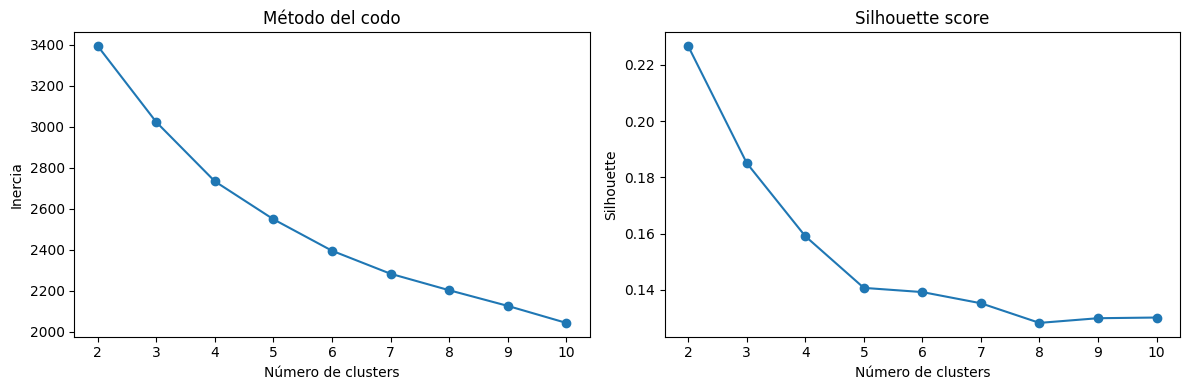

In [82]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_clustering, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, marker='o')
ax1.set_title('Método del codo')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inercia')

ax2.plot(k_range, silhouettes, marker='o')
ax2.set_title('Silhouette score')
ax2.set_xlabel('Número de clusters')
ax2.set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

Para determinar el número óptimo de clusters se utilizan dos métricas 
complementarias: el método del codo y el silhouette score.

El **método del codo** mide la inercia para cada valor de k, es decir, 
la suma de distancias de cada punto al centroide de su cluster. A medida 
que aumenta k la inercia siempre decrece, por lo que se busca el punto 
donde la reducción empieza a ser marginal. En este caso la curva desciende 
de forma suave y continua sin un codo claro, lo que indica que los datos 
no tienen una estructura de clusters muy marcada y separada.

El **silhouette score** mide simultáneamente la cohesión interna de cada 
cluster (qué tan compacto es) y su separación respecto al resto (qué tan 
distinto es de los demás). Un valor cercano a 1 indica clusters muy bien 
definidos y separados, mientras que valores cercanos a 0 indican clusters 
solapados. En este caso k=2 obtiene el silhouette más alto (0.23) pero 
ofrece poca riqueza interpretativa: solo distinguiría entre alta y baja 
actividad, información que ya captura la variable objetivo. A partir de 
k=4 el silhouette cae por debajo de 0.16 y los clusters se vuelven 
difíciles de interpretar.

Se selecciona **k=3** como número óptimo de clusters. Con un silhouette 
de 0.19 mantiene una separación razonable entre grupos y permite identificar 
tres perfiles de movilidad urbana claramente diferenciados que van más allá 
de la variable objetivo binaria, aportando valor interpretativo real al 
análisis.

### Entrenamiento con k=3

In [83]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_clustering)

data_clean['cluster'] = kmeans_final.labels_

print(data_clean['cluster'].value_counts())
print(data_clean.groupby('cluster')[['aforo_vehiculos', 'franja_horaria_Noche',
                                      'indice_ruido_historico', 'accidentes_previos_24h',
                                      'ocupacion_bus_pct', 'congestion_alta']].mean())

cluster
1    305
0    209
2    188
Name: count, dtype: int64
         aforo_vehiculos  franja_horaria_Noche  indice_ruido_historico  \
cluster                                                                  
0            1014.397129              0.598086               76.505742   
1            1875.652459              0.036066               96.318440   
2            1465.877660              0.111702               87.746534   

         accidentes_previos_24h  ocupacion_bus_pct  congestion_alta  
cluster                                                              
0                      2.972370          62.586259         0.564593  
1                      4.372924          76.076971         0.885246  
2                      3.573094          66.053064         0.696809  


### Identificación de clusters

Se aplica K-means con k=3 sobre las 10 variables más discriminativas 
seleccionadas por SelectKBest y escaladas con StandardScaler. El número 
de clusters se determina combinando el método del codo y el silhouette 
score: k=2 obtiene el silhouette más alto (0.23) pero solo distinguiría 
entre alta y baja actividad, información que ya captura la variable objetivo. 
k=3 mantiene un silhouette razonable (0.19) y permite identificar tres 
perfiles de movilidad urbana claramente diferenciados que aportan valor 
interpretativo más allá de la clasificación binaria.

#### Cluster 0 — Baja actividad urbana (209 registros)

Perfil predominantemente nocturno: el 60% de los registros corresponden 
a franja nocturna, con un aforo medio-bajo de 1014 vehículos, ruido 
histórico bajo (76.5), pocos accidentes previos (2.97) y baja ocupación 
del autobús (62.6%). La tasa de congestión alta es del 56%, la más baja 
de los tres clusters. Representa las franjas horarias de menor actividad 
urbana, donde la congestión es menos frecuente y las decisiones operativas 
del Ayuntamiento tienen menor urgencia.

#### Cluster 1 — Alta actividad urbana (305 registros)

Perfil claramente diurno: solo el 3.6% de los registros son nocturnos, 
con un aforo alto de 1875 vehículos, ruido histórico alto (96.3), muchos 
accidentes previos (4.37) y alta ocupación del autobús (76.1%). La tasa 
de congestión alta es del 88%, la más alta de los tres clusters. Representa 
las horas punta y días de máxima actividad urbana donde la congestión es 
casi sistemática y las medidas preventivas deberían activarse de forma 
prácticamente automática.

#### Cluster 2 — Actividad moderada (188 registros)

Perfil intermedio con aforo medio de 1465 vehículos, poca presencia 
nocturna (11%), ruido medio (87.7), accidentes medios (3.57) y ocupación 
de bus media (66%). La tasa de congestión alta es del 70%, entre los 
otros dos clusters. Representa situaciones donde la congestión es frecuente 
pero no sistemática. Este cluster es el más valioso desde el punto de 
vista operativo: son los casos en el límite donde la intervención anticipada 
del Ayuntamiento puede marcar la diferencia entre evitar o no el episodio 
de congestión.

### Evaluación del clustering

Se utilizan tres métricas internas para evaluar la calidad del clustering:

In [ ]:
#from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(X_clustering, kmeans_final.labels_)
davies_bouldin = davies_bouldin_score(X_clustering, kmeans_final.labels_)
calinski = calinski_harabasz_score(X_clustering, kmeans_final.labels_)

print(f"Silhouette score: {silhouette:.4f}")
print(f"Davies-Bouldin score: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz score: {calinski:.4f}")

Silhouette score: 0.1851
Davies-Bouldin score: 1.7557
Calinski-Harabasz score: 188.1571


El **silhouette score** de 0.185 indica una separación moderada entre 
clusters. Los valores cercanos a 1 indican clusters perfectamente separados 
y compactos, mientras que valores cercanos a 0 indican solapamiento. Un 
valor de 0.185 es bajo pero esperable en datos de movilidad urbana, donde 
las situaciones no tienen fronteras nítidas sino que forman un continuo 
(no existe un momento exacto en que la ciudad pasa de baja a alta actividad).

El **Davies-Bouldin score** de 1.756 mide la ratio entre la dispersión 
interna de cada cluster y la separación entre clusters. Valores más bajos 
indican mejor clustering, siendo 0 el valor óptimo. Un valor de 1.756 
confirma que los clusters tienen cierto solapamiento, coherente con el 
silhouette score.

El **Calinski-Harabasz score** de 188.16 mide la ratio entre la dispersión 
entre clusters y la dispersión interna. Valores más altos indican clusters 
más compactos y bien separados. En términos absolutos es difícil interpretar 
este valor sin compararlo con otros valores de k, pero es consistente con 
los resultados anteriores.

En conjunto las métricas confirman que los clusters tienen una separación 
moderada pero no perfecta, lo que es coherente con la naturaleza continua 
de los datos de movilidad urbana. A pesar de ello los tres perfiles 
identificados son interpretables y operativamente relevantes, lo que 
justifica la utilidad del clustering como herramienta de análisis 
complementaria al modelo supervisado.

### Visualización de los clusters (PCA)

Para visualizar los clusters en dos dimensiones se aplica PCA (Principal 
Component Analysis), que reduce las 10 variables seleccionadas a 2 
componentes principales que capturan la mayor parte de la varianza del 
dataset. Cada punto representa un registro: el color identifica el cluster 
(azul = Cluster 0, naranja = Cluster 1, verde = Cluster 2) y el marcador 
indica si hay congestión alta real (X) o no (círculo).

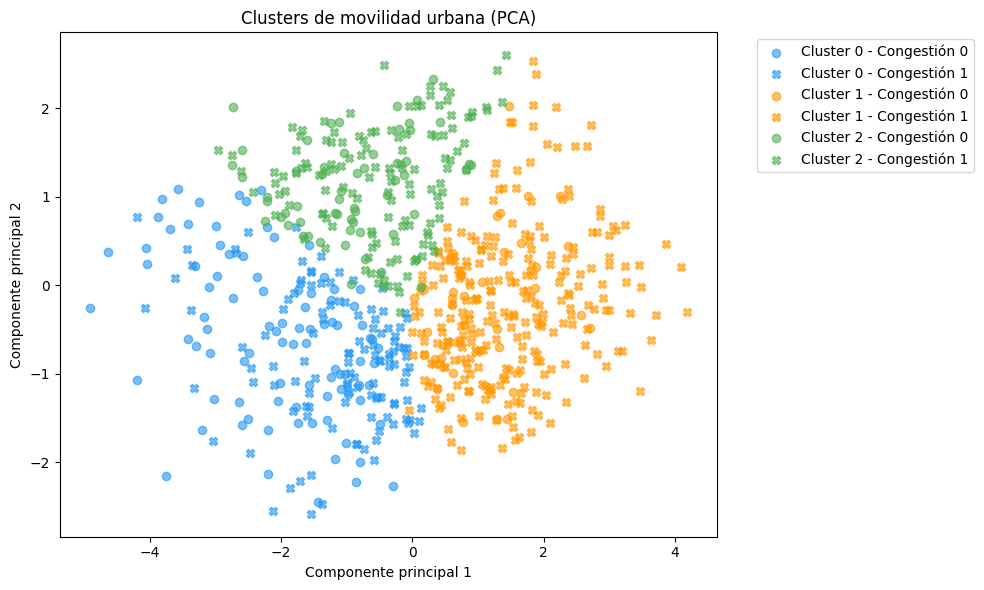

In [87]:
#from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

plt.figure(figsize=(10, 6))
colores_cluster = ['#2196F3', '#FF9800', '#4CAF50']
marcadores = {0: 'o', 1: 'X'}

for cluster in range(3):
    for congestion in [0, 1]:
        mask = (kmeans_final.labels_ == cluster) & (data_clean['congestion_alta'].values == congestion)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colores_cluster[cluster],
                   marker=marcadores[congestion],
                   alpha=0.6,
                   label=f'Cluster {cluster} - Congestión {congestion}')

plt.title('Clusters de movilidad urbana (PCA)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

El gráfico confirma visualmente los resultados de las métricas internas. 
Los tres clusters ocupan zonas diferenciadas del espacio: el Cluster 0 
(azul, baja actividad) se concentra en la zona izquierda, el Cluster 1 
(naranja, alta actividad) en la zona derecha y el Cluster 2 (verde, 
actividad moderada) en la zona central-superior. Sin embargo los bordes 
entre clusters se solapan, especialmente entre el Cluster 0 y el Cluster 2, 
lo que es coherente con el silhouette score de 0.185.

Dentro de cada cluster se observa la mezcla de círculos y X, confirmando 
que los clusters no replican la variable objetivo sino que capturan perfiles 
de movilidad más ricos. En el Cluster 1 (naranja) predominan claramente 
las X (congestión alta), coherente con su tasa del 88%. En el Cluster 0 
(azul) hay una mezcla más equilibrada de círculos y X, coherente con su 
tasa del 56%. El Cluster 2 (verde) muestra la mayor heterogeneidad, con 
muchos círculos en la zona superior y X distribuidas por toda su área, 
reflejando su tasa intermedia del 70% y confirmando que es el perfil más 
difícil de predecir y donde la intervención anticipada tiene mayor impacto.